In [1]:
# =========================================
# 1. CORE DATA HANDLING
# =========================================
import pandas as pd
import numpy as np

# =========================================
# 2. VISUALIZATION LIBRARIES
# =========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive visualizations
import plotly.express as px
import plotly.graph_objects as go

# Missing data visualization
import missingno as msno

# =========================================
# 3. STATISTICS & MODELLING
# =========================================
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# =========================================
# 4. GEOSPATIAL ANALYSIS (for borough + ZIP maps)
# =========================================
import geopandas as gpd
from shapely.geometry import Point, Polygon
import folium

print("All libraries imported successfully!")


All libraries imported successfully!


In [2]:
crime = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Visual Analytics/Team Project/Processed data/Complaints_2015-2025.csv')

In [3]:
print("Shape:", crime.shape)
crime.head()

Shape: (4880471, 12)


,Unnamed: 0,RPT_DT,OFNS_DESC,CRM_ATPT_CPTD_CD,LAW_CAT_CD,BORO_NM,LOC_OF_OCCUR_DESC,PREM_TYP_DESC,JURIS_DESC,Latitude,Longitude,YEAR
0,0,12/31/2024,GRAND LARCENY,COMPLETED,FELONY,MANHATTAN,INSIDE,RESIDENCE - APT. HOUSE,N.Y. POLICE DEPT,40.733533,-73.997532,2024
1,1,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,STATEN ISLAND,INSIDE,DEPARTMENT STORE,N.Y. POLICE DEPT,40.575324,-74.169839,2024
2,2,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,BRONX,INSIDE,RESIDENCE - PUBLIC HOUSING,N.Y. HOUSING POLICE,40.806508,-73.918839,2024
3,3,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,MANHATTAN,FRONT OF,PARK/PLAYGROUND,NYC PARKS,40.741957,-73.977927,2024
4,4,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,MANHATTAN,INSIDE,CHAIN STORE,N.Y. POLICE DEPT,40.722415,-73.999334,2024


In [4]:
# Drop the unwanted index column
crime = crime.drop(columns=["Unnamed: 0"], errors="ignore")

# Confirm
crime.columns

Index(['RPT_DT', 'OFNS_DESC', 'CRM_ATPT_CPTD_CD', 'LAW_CAT_CD', 'BORO_NM',
       'LOC_OF_OCCUR_DESC', 'PREM_TYP_DESC', 'JURIS_DESC', 'Latitude',
       'Longitude', 'YEAR'],
      dtype='object')

In [5]:
# Quick structure check
crime.info()

# Peek at a few rows
crime.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4880471 entries, 0 to 4880470
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   RPT_DT             object 
 1   OFNS_DESC          object 
 2   CRM_ATPT_CPTD_CD   object 
 3   LAW_CAT_CD         object 
 4   BORO_NM            object 
 5   LOC_OF_OCCUR_DESC  object 
 6   PREM_TYP_DESC      object 
 7   JURIS_DESC         object 
 8   Latitude           float64
 9   Longitude          float64
 10  YEAR               int64  
dtypes: float64(2), int64(1), object(8)
memory usage: 409.6+ MB


,RPT_DT,OFNS_DESC,CRM_ATPT_CPTD_CD,LAW_CAT_CD,BORO_NM,LOC_OF_OCCUR_DESC,PREM_TYP_DESC,JURIS_DESC,Latitude,Longitude,YEAR
0,12/31/2024,GRAND LARCENY,COMPLETED,FELONY,MANHATTAN,INSIDE,RESIDENCE - APT. HOUSE,N.Y. POLICE DEPT,40.733533,-73.997532,2024
1,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,STATEN ISLAND,INSIDE,DEPARTMENT STORE,N.Y. POLICE DEPT,40.575324,-74.169839,2024
2,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,BRONX,INSIDE,RESIDENCE - PUBLIC HOUSING,N.Y. HOUSING POLICE,40.806508,-73.918839,2024
3,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,MANHATTAN,FRONT OF,PARK/PLAYGROUND,NYC PARKS,40.741957,-73.977927,2024
4,12/31/2024,PETIT LARCENY,COMPLETED,MISDEMEANOR,MANHATTAN,INSIDE,CHAIN STORE,N.Y. POLICE DEPT,40.722415,-73.999334,2024


In [6]:
# Convert RPT_DT from string like "12/31/2024" to datetime
crime['RPT_DT'] = pd.to_datetime(crime['RPT_DT'], format="%m/%d/%Y", errors='coerce')

# Create a year column from the date (for sanity check)
crime['YEAR_FROM_DATE'] = crime['RPT_DT'].dt.year

# Quick check: how do YEAR (given) and YEAR_FROM_DATE compare?
year_compare = (
    crime[['YEAR', 'YEAR_FROM_DATE']]
    .dropna()
    .assign(match=lambda df: df['YEAR'] == df['YEAR_FROM_DATE'])
)

print("Total rows checked:", len(year_compare))
print("Rows where YEAR matches YEAR_FROM_DATE:", year_compare['match'].sum())
print("Rows where YEAR does NOT match:", (~year_compare['match']).sum())

# Also see the unique YEAR values
print("Unique YEAR values:", sorted(crime['YEAR'].unique()))


Total rows checked: 4880471
Rows where YEAR matches YEAR_FROM_DATE: 4880471
Rows where YEAR does NOT match: 0
Unique YEAR values: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


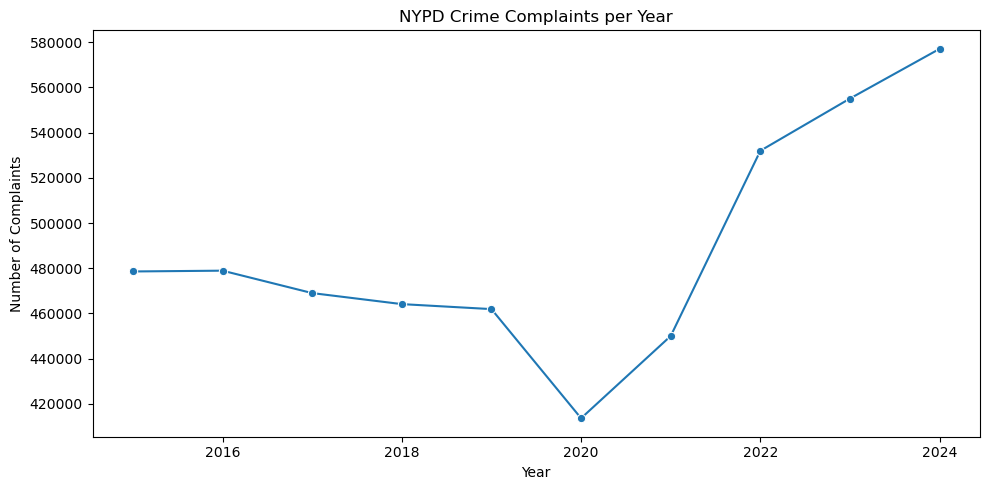

In [7]:
# Aggregate counts per year
year_counts = crime['YEAR'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o')
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.title("NYPD Crime Complaints per Year")
plt.tight_layout()
plt.show()


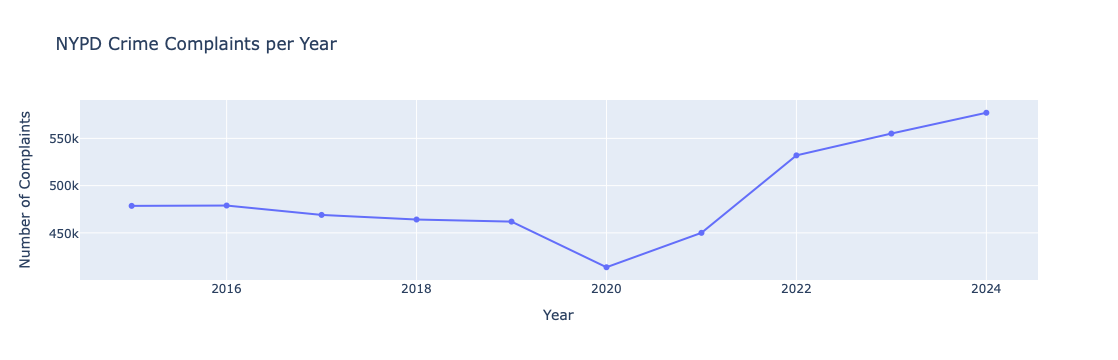

In [8]:
#Interactive
fig = px.line(
    x=year_counts.index,
    y=year_counts.values,
    markers=True,
    labels={"x": "Year", "y": "Number of Complaints"},
    title="NYPD Crime Complaints per Year"
)
fig.show()

In [9]:
crime['BORO_NM'].value_counts(dropna=False)

BORO_NM
BROOKLYN         1398940
MANHATTAN        1187498
BRONX            1060025
QUEENS           1017083
STATEN ISLAND     213209
(null)              3716
Name: count, dtype: int64

In [10]:
# 1. Treat "(null)" as missing
crime['BORO_NM'] = crime['BORO_NM'].replace('(null)', np.nan)

In [11]:
# 2. Drop old columns if they exist from previous attempts
crime = crime.drop(columns=['BORO_NM_FROM_COORDS', 'BORO_NM_IMPUTED'], errors='ignore')

In [12]:
# 3. Build lookup (Latitude, Longitude) -> most common BORO_NM
known_boro = crime[
    crime['BORO_NM'].notna() &
    crime['Latitude'].notna() &
    crime['Longitude'].notna()
].copy()

boro_lookup = (
    known_boro
    .groupby(['Latitude', 'Longitude'])['BORO_NM']
    .agg(lambda x: x.mode().iloc[0])   # most frequent borough at that coord
    .reset_index()
    .rename(columns={'BORO_NM': 'BORO_NM_FROM_COORDS'})
)

print("Rows in boro_lookup (unique coords with known borough):", boro_lookup.shape[0])


Rows in boro_lookup (unique coords with known borough): 142875


In [13]:
# 4. Merge lookup back onto main data
crime = crime.merge(
    boro_lookup,
    on=['Latitude', 'Longitude'],
    how='left'
)

In [14]:
# 5. Build final imputed borough column
crime['BORO_NM_IMPUTED'] = crime['BORO_NM']

# Use coord-based borough where original is missing
mask_use_coords = crime['BORO_NM_IMPUTED'].isna() & crime['BORO_NM_FROM_COORDS'].notna()
crime.loc[mask_use_coords, 'BORO_NM_IMPUTED'] = crime.loc[mask_use_coords, 'BORO_NM_FROM_COORDS']

# Anything still missing becomes 'UNKNOWN'
crime['BORO_NM_IMPUTED'] = crime['BORO_NM_IMPUTED'].fillna('UNKNOWN')

In [15]:
print(crime['BORO_NM_IMPUTED'].value_counts())

BORO_NM_IMPUTED
BROOKLYN         1399014
MANHATTAN        1191010
BRONX            1060080
QUEENS           1017123
STATEN ISLAND     213214
UNKNOWN               30
Name: count, dtype: int64


In [16]:
# Filter out UNKNOWN boroughs
crime_clean = crime[crime['BORO_NM_IMPUTED'] != 'UNKNOWN'].copy()

# Build borough counts safely
borough_counts = (
    crime_clean['BORO_NM_IMPUTED']
    .value_counts()
    .reset_index()
)

# Rename columns reliably
borough_counts.columns = ['BOROUGH', 'COUNT']

borough_counts

,BOROUGH,COUNT
0,BROOKLYN,1399014
1,MANHATTAN,1191010
2,BRONX,1060080
3,QUEENS,1017123
4,STATEN ISLAND,213214


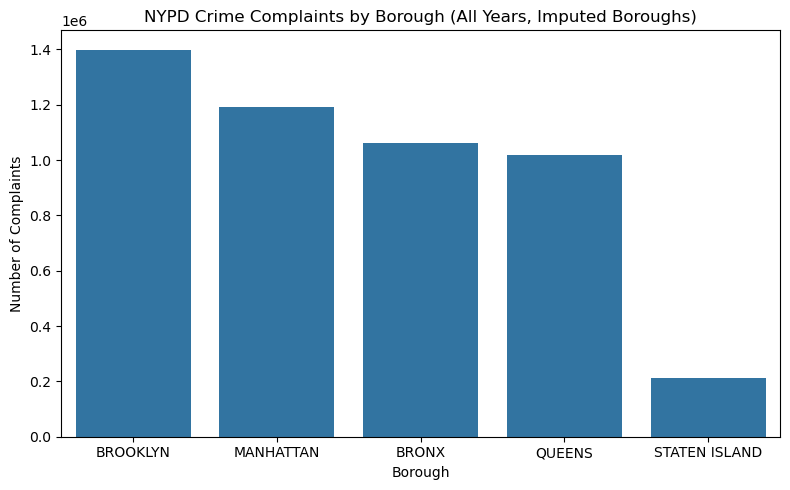

In [17]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=borough_counts,
    x='BOROUGH',
    y='COUNT'
)

plt.xlabel("Borough")
plt.ylabel("Number of Complaints")
plt.title("NYPD Crime Complaints by Borough (All Years, Imputed Boroughs)")
plt.tight_layout()
plt.show()

In [18]:
fig = px.bar(
    borough_counts,
    x='BOROUGH',
    y='COUNT',
    title="NYPD Crime Complaints by Borough (All Years)",
    labels={'BOROUGH': 'Borough', 'COUNT': 'Number of Complaints'}
)
fig.show()


In [19]:
# Keep only rows with valid lat/long
crime_geo = crime_clean.dropna(subset=['Latitude', 'Longitude']).copy()

print("Total rows with valid coordinates:", crime_geo.shape[0])
crime_geo[['Latitude', 'Longitude']].describe()

Total rows with valid coordinates: 4880441


,Latitude,Longitude
count,4.880441e+06,4.880441e+06
mean,4.073632e+01,-7.392397e+01
std,1.154057e-01,1.649930e-01
min,0.000000e+00,-7.425495e+01
25%,4.067450e+01,-7.397313e+01
50%,4.073443e+01,-7.392666e+01
75%,4.081211e+01,-7.388112e+01
max,4.091271e+01,0.000000e+00


In [20]:
import folium
from folium.plugins import HeatMap

# Center roughly on NYC
center_lat, center_lon = 40.7128, -74.0060

# Sample for performance (adjust n if it errors / lags)
sample_size = 50000
crime_sample = crime_geo.sample(
    n=min(sample_size, len(crime_geo)),
    random_state=42
)

# Create base map
m = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles='cartodbpositron')

# Build list of [lat, lon] points
heat_data = crime_sample[['Latitude', 'Longitude']].values.tolist()

# Add heatmap layer
HeatMap(
    heat_data,
    radius=6,      # how "wide" each point appears
    blur=8,
    max_zoom=13
).add_to(m)

m


In [21]:
import folium
from folium.plugins import HeatMap
import branca.colormap as cm

# Center of NYC
center_lat, center_lon = 40.7128, -74.0060

# Sample for map performance
sample_size = 50000
crime_sample = crime_geo.sample(
    n=min(sample_size, len(crime_geo)),
    random_state=42
)

# ============================
# 1. Create color scale legend
# ============================
colormap = cm.LinearColormap(
    colors=['blue', 'lime', 'yellow', 'orange', 'red'],
    vmin=0,              # lowest density
    vmax=1,              # highest density
    caption='Complaint Density'
)

# ============================
# 2. Create the map
# ============================
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=10,
    tiles="cartodbpositron"
)

# Add HeatMap
HeatMap(
    data=crime_sample[['Latitude', 'Longitude']].values.tolist(),
    radius=6,
    blur=8,
    max_zoom=13
).add_to(m)

# Add legend to map
colormap.add_to(m)

m


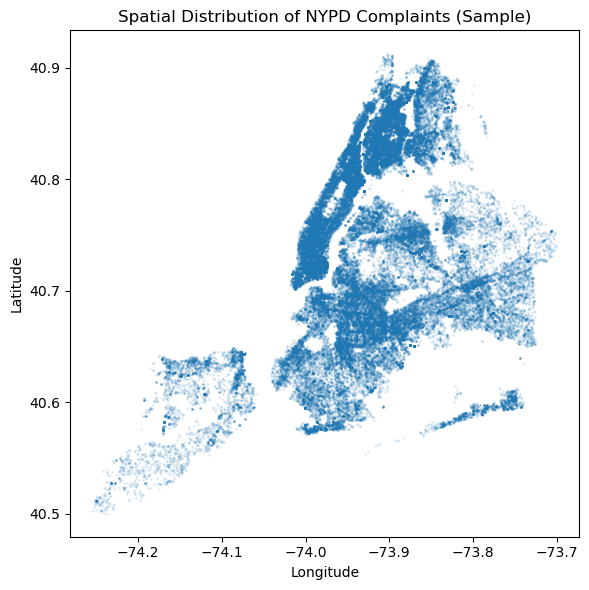

In [22]:
plt.figure(figsize=(6, 6))

# Smaller sample for scatter
scatter_sample = crime_geo.sample(
    n=min(100000, len(crime_geo)),
    random_state=42
)

plt.scatter(
    scatter_sample['Longitude'],
    scatter_sample['Latitude'],
    s=1,
    alpha=0.1
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of NYPD Complaints (Sample)")
plt.tight_layout()
plt.show()


In [23]:
#Aggregate type 1
from folium.plugins import HeatMap
import folium
import numpy as np

# Start from data with valid borough & coords
crime_geo_full = crime_clean.dropna(subset=['Latitude', 'Longitude']).copy()
print("Rows with valid coords:", crime_geo_full.shape[0])

# Aggregate: round coordinates to ~3 decimal places (~100m grid)
crime_geo_full['lat_round'] = crime_geo_full['Latitude'].round(3)
crime_geo_full['lon_round'] = crime_geo_full['Longitude'].round(3)

heat_agg = (
    crime_geo_full
    .groupby(['lat_round', 'lon_round'])
    .size()
    .reset_index(name='weight')
)

print("Number of aggregated grid points:", heat_agg.shape[0])
heat_agg.head()


Rows with valid coords: 4880441
Number of aggregated grid points: 52820


,lat_round,lon_round,weight
0,0.000,0.000,19
1,40.499,-74.244,4
2,40.499,-74.243,1
3,40.499,-74.242,11
4,40.499,-74.241,5


In [24]:
# Center on NYC
center_lat, center_lon = 40.7128, -74.0060

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=10,
    tiles="cartodbpositron"
)

# Build [lat, lon, weight] list
heat_data_full = heat_agg[['lat_round', 'lon_round', 'weight']].values.tolist()

HeatMap(
    heat_data_full,
    radius=6,
    blur=8,
    max_zoom=13,
).add_to(m)

m

In [25]:
import geopandas as gpd

# Path to your borough boundaries file (GeoJSON or shapefile)
# Example: "data/nyc_borough_boundaries.geojson"
boroughs_path = "https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/arcgis/rest/services/NYC_Borough_Boundary/FeatureServer/0/query?where=1=1&outFields=*&outSR=4326&f=pgeojson"  # <-- change this

boroughs_gdf = gpd.read_file(boroughs_path)

# (Optional) Reproject to WGS84 if needed
if boroughs_gdf.crs and boroughs_gdf.crs.to_string() != "EPSG:4326":
    boroughs_gdf = boroughs_gdf.to_crs(epsg=4326)

boroughs_gdf.head()


DataSourceError: Failed to read GeoJSON data; At line 75173, character 49: Unterminated object

In [ ]:
# Style function for borough borders
def style_boroughs(feature):
    return {
        'fillColor': 'none',
        'color': 'black',   # border color
        'weight': 1.5,
        'fillOpacity': 0
    }

folium.GeoJson(
    boroughs_gdf,
    name="Borough Boundaries",
    style_function=style_boroughs,
    tooltip=folium.GeoJsonTooltip(
        fields=[boroughs_gdf.columns[0]],  # often 'boro_name' or similar
        aliases=["Borough:"]
    )
).add_to(m)

folium.LayerControl().add_to(m)

m


In [ ]:
import branca.colormap as cm

colormap = cm.LinearColormap(
    colors=['blue', 'lime', 'yellow', 'orange', 'red'],
    vmin=0,
    vmax=heat_agg['weight'].max(),  # scale to max density
    caption='Complaint Density (Aggregated)'
)

colormap.add_to(m)
m


In [ ]:
# seriousness mapping
serious_map = {"FELONY": 3, "MISDEMEANOR": 2, "VIOLATION": 1}
crime_clean['serious_score'] = crime_clean['LAW_CAT_CD'].map(serious_map)

agg_boro_year = (
    crime_clean
    .groupby(['BORO_NM_IMPUTED', 'YEAR'])
    .agg(
        total_complaints=('YEAR', 'size'),
        avg_seriousness=('serious_score', 'mean')
    )
    .reset_index()
)

# seriousness index = avg seriousness * volume
agg_boro_year['serious_index'] = (
    agg_boro_year['avg_seriousness'] * agg_boro_year['total_complaints']
)

In [ ]:
import plotly.express as px

fig = px.scatter(
    agg_boro_year.sort_values('YEAR'),
    x="YEAR",
    y="total_complaints",
    color="BORO_NM_IMPUTED",          # color = borough
    size="serious_index",             # size = seriousness * volume
    size_max=40,                      # cap max bubble size
    hover_data=["BORO_NM_IMPUTED", "total_complaints", "avg_seriousness"],
    title="NYC Crime Complaints by Year & Borough<br>"
          "<sub>Color = Borough, Size = Seriousness of Crime Mix</sub>",
    template="plotly_white"
)

# markers only, no lines
fig.update_traces(mode="markers", marker=dict(opacity=0.8, line=dict(width=0.5, color="white")))

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Total Complaints",
    legend_title="Borough",
    height=600
)

fig.show()

In [26]:
fig = px.scatter(
    agg_boro_year,
    x="total_complaints",
    y="avg_seriousness",
    color="BORO_NM_IMPUTED",
    size="serious_index",
    size_max=40,
    template="plotly_white",
    title="Crime Volume vs Seriousness by Borough & Year"
)

NameError: name 'agg_boro_year' is not defined

In [27]:
fig = px.scatter(
    agg_boro_year.sort_values("YEAR"),
    x="YEAR",
    y="total_complaints",
    color="BORO_NM_IMPUTED",
    size="avg_seriousness",
    hover_data=["avg_seriousness"],
    facet_col="BORO_NM_IMPUTED",
    facet_col_wrap=3,
    title="NYC Crime Trends by Borough (Bubble = Seriousness)"
)
fig.update_traces(mode="lines+markers")
fig.show()


NameError: name 'agg_boro_year' is not defined

In [28]:
# Make sure date is datetime
crime['RPT_DT'] = pd.to_datetime(crime['RPT_DT'], errors='coerce')

# Keep only rows with a valid date and borough
crime_cal = crime.copy()
crime_cal = crime_cal[crime_cal['RPT_DT'].notna()]
crime_cal = crime_cal[crime_cal['BORO_NM_IMPUTED'] != 'UNKNOWN']

# Month number (1–12)
crime_cal['MONTH'] = crime_cal['RPT_DT'].dt.month

In [29]:
month_boro = (
    crime_cal
    .groupby(['BORO_NM_IMPUTED', 'MONTH'])
    .size()
    .reset_index(name='count')
)

# Pivot so each row = borough, each column = month 1..12
month_boro_pivot = month_boro.pivot(
    index='BORO_NM_IMPUTED',
    columns='MONTH',
    values='count'
).fillna(0)

month_boro_pivot

MONTH,1,2,3,4,5,6,7,8,9,10,11,12
BORO_NM_IMPUTED,,,,,,,,,,,,
BRONX,84913,76621,86479,83288,92556,90492,94100,94608,90453,93564,87079,85927
BROOKLYN,111985,100941,113342,109426,121796,120457,125363,126298,120176,122817,114861,111552
MANHATTAN,94065,86744,95472,93828,101604,102365,104829,106880,103163,107447,98203,96410
QUEENS,79929,74127,80779,79311,87875,87926,91559,91723,86885,89250,84039,83720
STATEN ISLAND,16807,15472,17554,17053,18755,18420,18888,18507,18210,18797,17471,17280


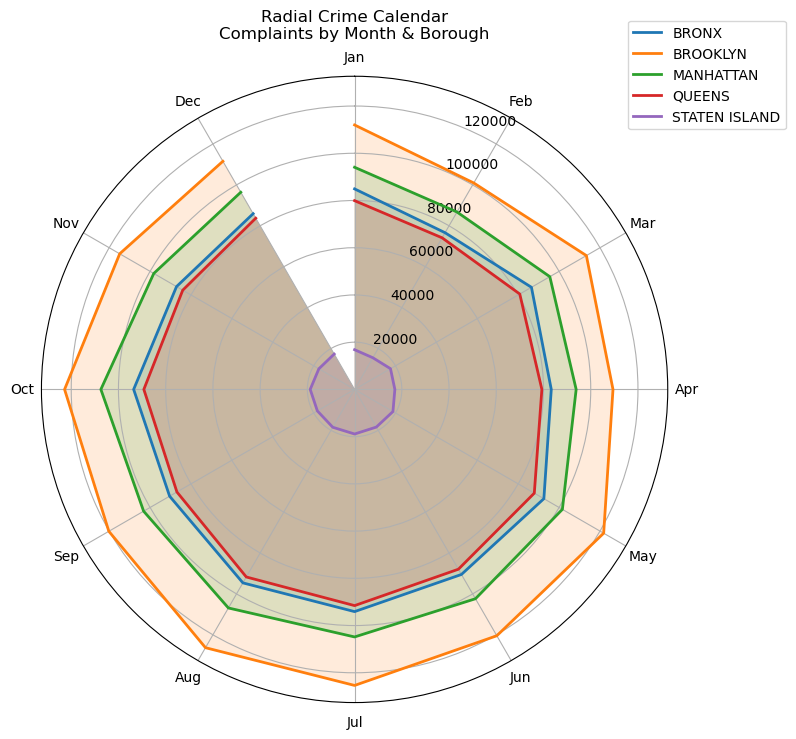

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure months 1–12 in correct order
months = np.arange(1, 13)
theta = 2 * np.pi * (months - 1) / 12  # angle per month

# Reindex columns so they’re 1..12 in order
month_boro_pivot = month_boro_pivot.reindex(columns=months, fill_value=0)

# Create polar plot
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# One line per borough
for boro, row in month_boro_pivot.iterrows():
    r = row.values  # counts for months 1..12
    ax.plot(theta, r, linewidth=2, label=boro)
    ax.fill_between(theta, 0, r, alpha=0.15)  # soft area under curve

# Month labels around the circle
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticks(theta)
ax.set_xticklabels(month_labels)

# Optional: remove radial grid clutter a bit
ax.set_theta_direction(-1)          # clockwise
ax.set_theta_offset(np.pi / 2.0)    # start at top (Jan at 12 o’clock)

ax.set_title("Radial Crime Calendar\nComplaints by Month & Borough", va='bottom')
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.show()


In [31]:
# Start from crime, optionally drop UNKNOWN boroughs
df = crime.copy()
if 'BORO_NM_IMPUTED' in df.columns:
    df = df[df['BORO_NM_IMPUTED'] != 'UNKNOWN']

# Keep only needed columns and drop missing
df = df[['OFNS_DESC', 'PREM_TYP_DESC']].dropna()

# Top 15 offenses
top_offenses = df['OFNS_DESC'].value_counts().head(15).index

# Top 10 premises
top_premises = df['PREM_TYP_DESC'].value_counts().head(10).index

# Filter to those
df_sub = df[
    df['OFNS_DESC'].isin(top_offenses) &
    df['PREM_TYP_DESC'].isin(top_premises)
].copy()


In [32]:
# Crosstab: rows = offense, cols = premise
heat = pd.crosstab(df_sub['OFNS_DESC'], df_sub['PREM_TYP_DESC'])

# Sort offenses (rows) and premises (cols) by total volume
row_order = heat.sum(axis=1).sort_values(ascending=False).index
col_order = heat.sum(axis=0).sort_values(ascending=False).index

heat_sorted = heat.loc[row_order, col_order]

# Log transform to tame huge differences
heat_log = np.log1p(heat_sorted)   # log(1 + count)

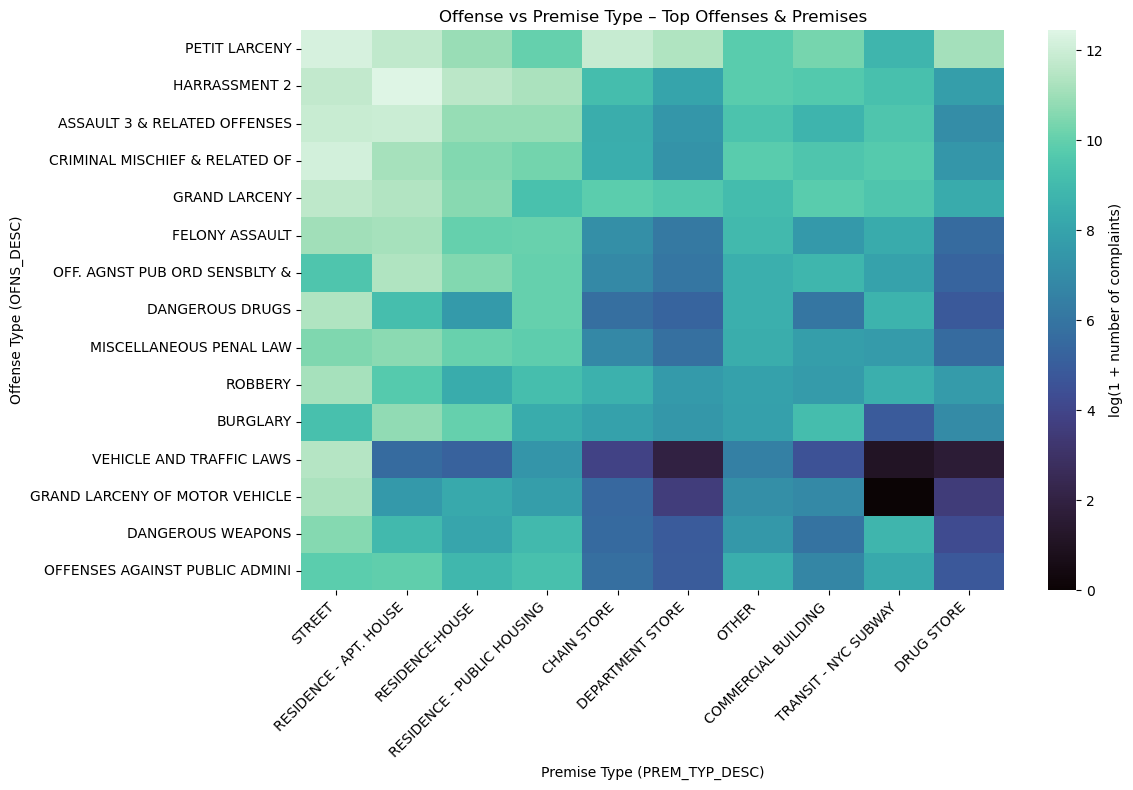

In [33]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    heat_log,
    cmap="mako",                      # or "viridis", "cubehelix", etc.
    cbar_kws={'label': 'log(1 + number of complaints)'},
)

plt.title("Offense vs Premise Type – Top Offenses & Premises")
plt.xlabel("Premise Type (PREM_TYP_DESC)")
plt.ylabel("Offense Type (OFNS_DESC)")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [34]:
boro = "MANHATTAN"
df_boro = crime[
    (crime['BORO_NM_IMPUTED'] == boro) &
    crime['OFNS_DESC'].notna() &
    crime['PREM_TYP_DESC'].notna()
][['OFNS_DESC', 'PREM_TYP_DESC']]
# then repeat the same steps on df_boro instead of df

Rows for MANHATTAN: 1,191,010
Rows after restricting to top offenses/premises: 864,140


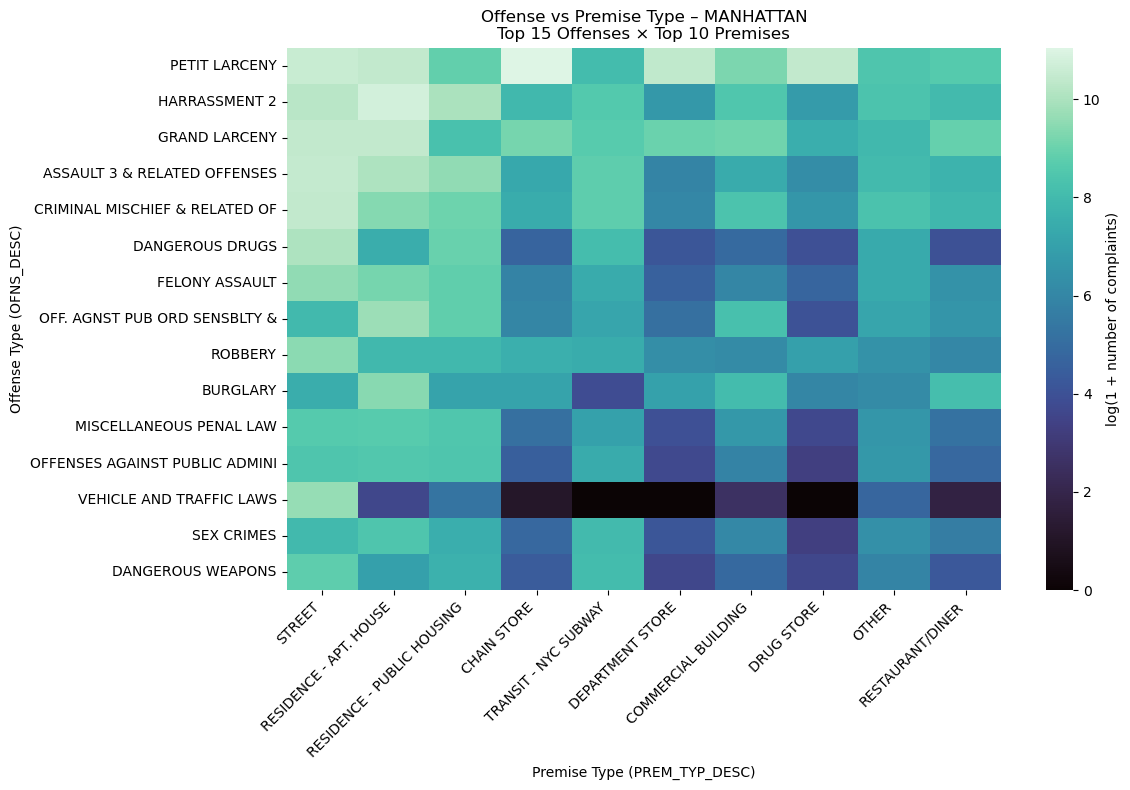

In [35]:
# =============== SETTINGS ===============
# Change this to any borough you want:
# 'MANHATTAN', 'BROOKLYN', 'BRONX', 'QUEENS', 'STATEN ISLAND'
boro = "MANHATTAN"
top_n_offenses = 15
top_n_premises = 10
# =======================================

# 1. Filter to chosen borough and keep needed columns
df_boro = crime.copy()

# Use imputed borough if available
if 'BORO_NM_IMPUTED' in df_boro.columns:
    df_boro = df_boro[df_boro['BORO_NM_IMPUTED'] == boro]
else:
    df_boro = df_boro[df_boro['BORO_NM'] == boro]

df_boro = df_boro[['OFNS_DESC', 'PREM_TYP_DESC']].dropna()

print(f"Rows for {boro}: {len(df_boro):,}")

# 2. Select top offenses and premises within this borough
top_offenses = df_boro['OFNS_DESC'].value_counts().head(top_n_offenses).index
top_premises = df_boro['PREM_TYP_DESC'].value_counts().head(top_n_premises).index

df_sub = df_boro[
    df_boro['OFNS_DESC'].isin(top_offenses) &
    df_boro['PREM_TYP_DESC'].isin(top_premises)
].copy()

print(f"Rows after restricting to top offenses/premises: {len(df_sub):,}")

# 3. Build offense × premise matrix
heat = pd.crosstab(df_sub['OFNS_DESC'], df_sub['PREM_TYP_DESC'])

# Sort rows and columns by total volume
row_order = heat.sum(axis=1).sort_values(ascending=False).index
col_order = heat.sum(axis=0).sort_values(ascending=False).index
heat_sorted = heat.loc[row_order, col_order]

# Log-transform to compress large differences
heat_log = np.log1p(heat_sorted)   # log(1 + count)

# 4. Plot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    heat_log,
    cmap="mako",  # you can try "viridis", "rocket", "cubehelix"
    cbar_kws={'label': 'log(1 + number of complaints)'}
)

plt.title(f"Offense vs Premise Type – {boro}\nTop {top_n_offenses} Offenses × Top {top_n_premises} Premises")
plt.xlabel("Premise Type (PREM_TYP_DESC)")
plt.ylabel("Offense Type (OFNS_DESC)")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Rows used: 4455436


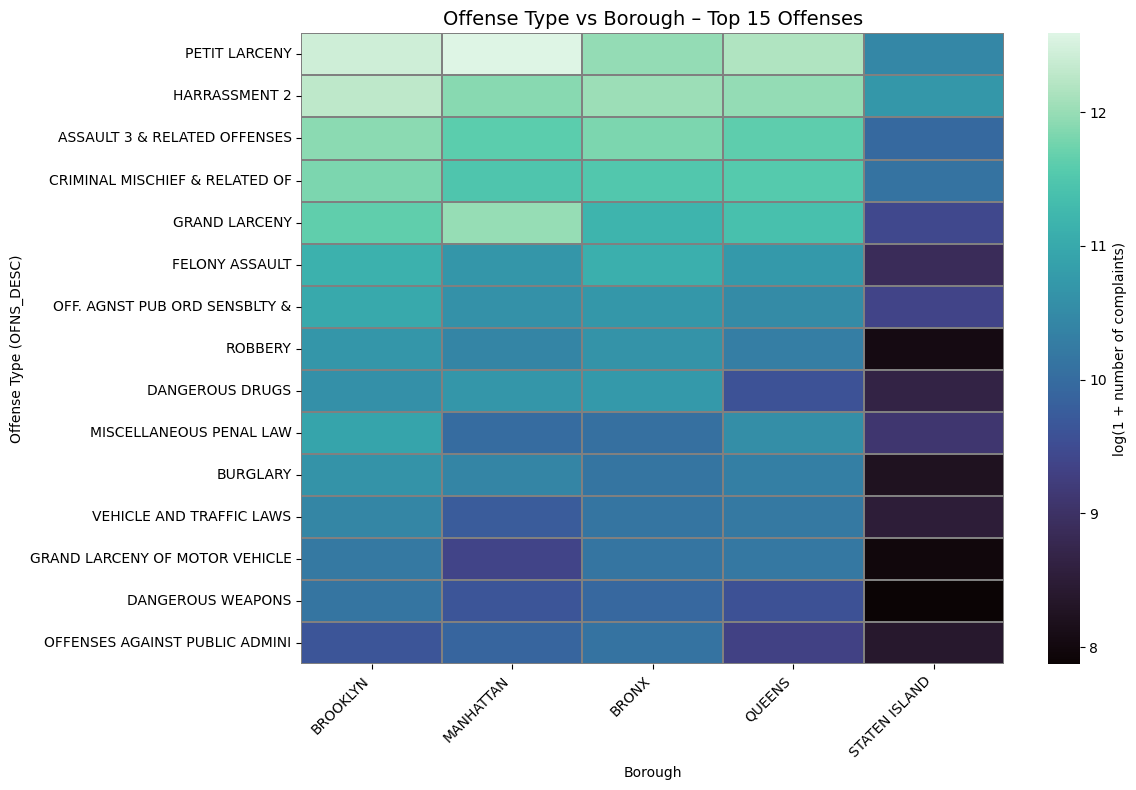

In [36]:
# =========================================================
# 1. Prepare data (use your imputed borough column)
# =========================================================
df = crime.copy()

# Drop UNKNOWN boroughs
df = df[df['BORO_NM_IMPUTED'] != 'UNKNOWN']

# Keep only offense + borough columns and drop missing
df = df[['OFNS_DESC', 'BORO_NM_IMPUTED']].dropna()

# =========================================================
# 2. Pick top 15 offenses
# =========================================================
top_offenses = df['OFNS_DESC'].value_counts().head(15).index

df_sub = df[df['OFNS_DESC'].isin(top_offenses)].copy()

print("Rows used:", len(df_sub))

# =========================================================
# 3. Build OFFENSE × BOROUGH matrix
# =========================================================
heat = pd.crosstab(
    df_sub['OFNS_DESC'],
    df_sub['BORO_NM_IMPUTED']
)

# Sort rows by total volume (top offenses first)
row_order = heat.sum(axis=1).sort_values(ascending=False).index

# Sort boroughs by total crime (optional)
col_order = heat.sum(axis=0).sort_values(ascending=False).index

heat_sorted = heat.loc[row_order, col_order]

# Log-transform to reduce extreme differences
heat_log = np.log1p(heat_sorted)

# =========================================================
# 4. Plot heatmap
# =========================================================
plt.figure(figsize=(12, 8))

sns.heatmap(
    heat_log,
    cmap="mako",  # dark-to-light gradient
    linewidths=0.3,
    linecolor="gray",
    cbar_kws={'label': 'log(1 + number of complaints)'}
)

plt.title("Offense Type vs Borough – Top 15 Offenses", fontsize=14)
plt.xlabel("Borough")
plt.ylabel("Offense Type (OFNS_DESC)")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Rows used: 4455436


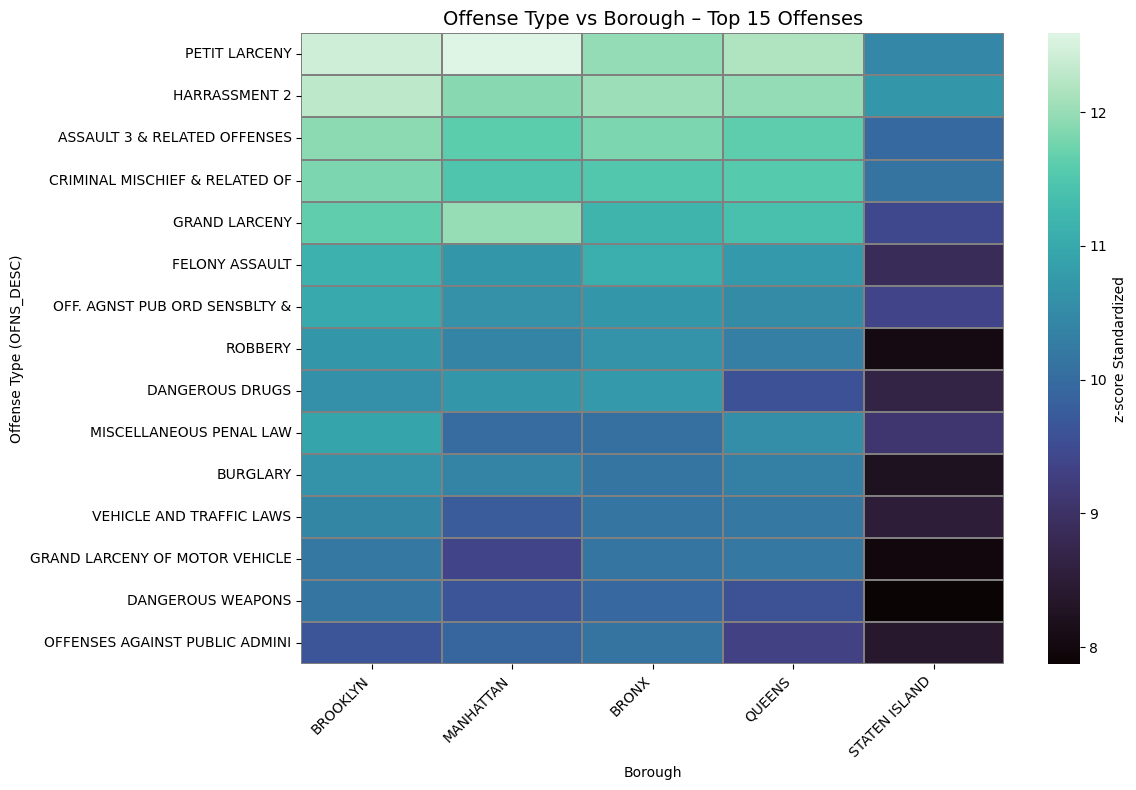

In [37]:
# =========================================================
# 1. Prepare data (use your imputed borough column)
# =========================================================
df = crime.copy()

# Drop UNKNOWN boroughs
df = df[df['BORO_NM_IMPUTED'] != 'UNKNOWN']

# Keep only offense + borough columns and drop missing
df = df[['OFNS_DESC', 'BORO_NM_IMPUTED']].dropna()

# =========================================================
# 2. Pick top 15 offenses
# =========================================================
top_offenses = df['OFNS_DESC'].value_counts().head(15).index

df_sub = df[df['OFNS_DESC'].isin(top_offenses)].copy()

print("Rows used:", len(df_sub))

# =========================================================
# 3. Build OFFENSE × BOROUGH matrix
# =========================================================
heat = pd.crosstab(
    df_sub['OFNS_DESC'],
    df_sub['BORO_NM_IMPUTED']
)

# Sort rows by total volume (top offenses first)
row_order = heat.sum(axis=1).sort_values(ascending=False).index

# Sort boroughs by total crime (optional)
col_order = heat.sum(axis=0).sort_values(ascending=False).index

heat_sorted = heat.loc[row_order, col_order]

# Log-transform to reduce extreme differences
heat_z = (heat_sorted - heat_sorted.mean()) / heat_sorted.std()

# =========================================================
# 4. Plot heatmap
# =========================================================
plt.figure(figsize=(12, 8))

sns.heatmap(
    heat_log,
    cmap="mako",  # dark-to-light gradient
    linewidths=0.3,
    linecolor="gray",
    cbar_kws={'label': 'z-score Standardized'}
)

plt.title("Offense Type vs Borough – Top 15 Offenses", fontsize=14)
plt.xlabel("Borough")
plt.ylabel("Offense Type (OFNS_DESC)")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
crime['OFNS_DESC'].unique()

array(['GRAND LARCENY', 'PETIT LARCENY', 'ROBBERY',
       'MISCELLANEOUS PENAL LAW', 'CRIMINAL MISCHIEF & RELATED OF',
       'POSSESSION OF STOLEN PROPERTY', 'OFFENSES AGAINST PUBLIC ADMINI',
       'DANGEROUS DRUGS', 'HARRASSMENT 2', 'CRIMINAL TRESPASS',
       'ASSAULT 3 & RELATED OFFENSES', 'FORGERY', 'FELONY ASSAULT',
       'BURGLARY', 'SEX CRIMES', 'OTHER OFFENSES RELATED TO THEFT',
       'OTHER STATE LAWS', 'MURDER & NON-NEGL. MANSLAUGHTER',
       'INTOXICATED & IMPAIRED DRIVING',
       'OTHER STATE LAWS (NON PENAL LAW)', 'RAPE', 'DANGEROUS WEAPONS',
       'GRAND LARCENY OF MOTOR VEHICLE', 'OFFENSES INVOLVING FRAUD',
       'VEHICLE AND TRAFFIC LAWS', 'OFF. AGNST PUB ORD SENSBLTY &',
       "BURGLAR'S TOOLS", 'THEFT-FRAUD', 'UNAUTHORIZED USE OF A VEHICLE',
       'JOSTLING', 'OFFENSES AGAINST THE PERSON', 'FRAUDS',
       'ADMINISTRATIVE CODE', 'ARSON', 'PETIT LARCENY OF MOTOR VEHICLE',
       'ALCOHOLIC BEVERAGE CONTROL LAW', 'CANNABIS RELATED OFFENSES',
       'CHILD ABA

Total rows used: 4880441


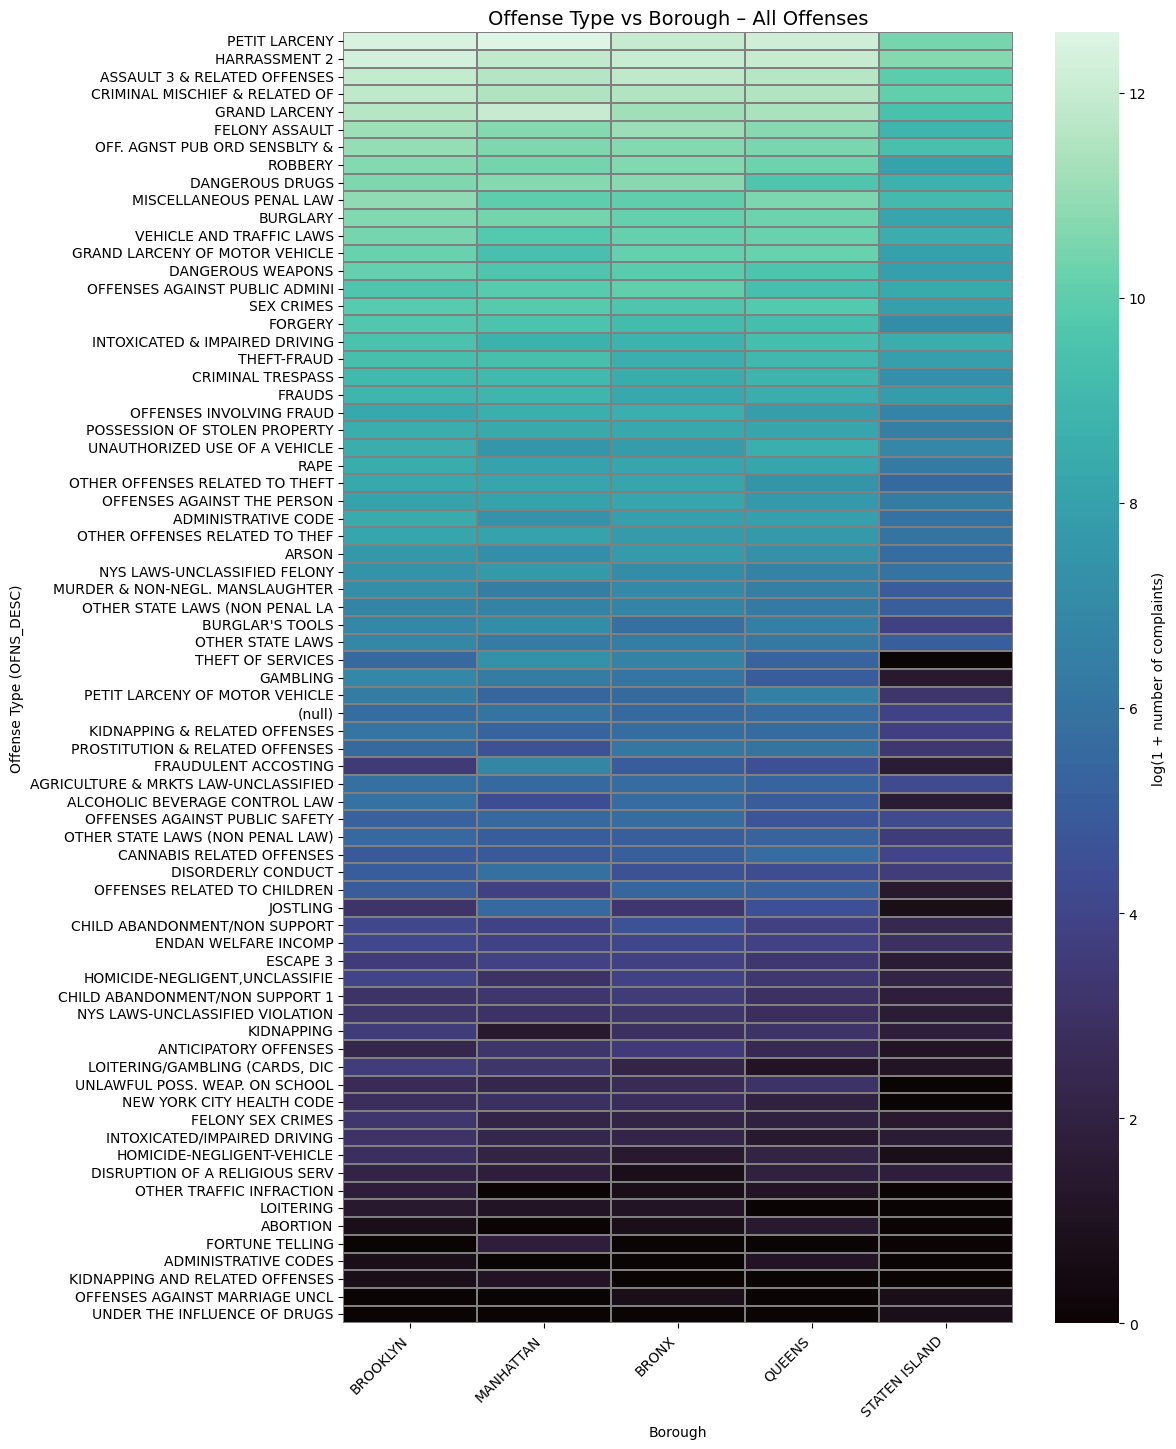

In [39]:
df = crime.copy()

# Use imputed boroughs and drop UNKNOWN
if 'BORO_NM_IMPUTED' in df.columns:
    df = df[df['BORO_NM_IMPUTED'] != 'UNKNOWN']
    boro_col = 'BORO_NM_IMPUTED'
else:
    # fallback if you didn't create the imputed column
    boro_col = 'BORO_NM'
    df = df[df[boro_col] != '(null)']

# Keep only offense + borough columns and drop missing
df = df[['OFNS_DESC', boro_col]].dropna()

print("Total rows used:", len(df))

# =========================================================
# 2. Build OFFENSE × BOROUGH matrix (all offenses)
# =========================================================

heat = pd.crosstab(
    df['OFNS_DESC'],
    df[boro_col]
)

# Sort rows (offenses) by total volume descending
row_order = heat.sum(axis=1).sort_values(ascending=False).index

# Sort columns (boroughs) by total volume descending
col_order = heat.sum(axis=0).sort_values(ascending=False).index

heat_sorted = heat.loc[row_order, col_order]

# Log-transform for smoother gradient: log(1 + count)
heat_log = np.log1p(heat_sorted)

# =========================================================
# 3. Plot heatmap
# =========================================================

plt.figure(figsize=(12, max(8, len(heat_log) * 0.2)))  # dynamic height

sns.heatmap(
    heat_log,
    cmap="mako",              # nice dark-to-light gradient
    linewidths=0.2,
    linecolor="gray",
    cbar_kws={'label': 'log(1 + number of complaints)'}
)

plt.title("Offense Type vs Borough – All Offenses", fontsize=14)
plt.xlabel("Borough")
plt.ylabel("Offense Type (OFNS_DESC)")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Total rows used: 4880441


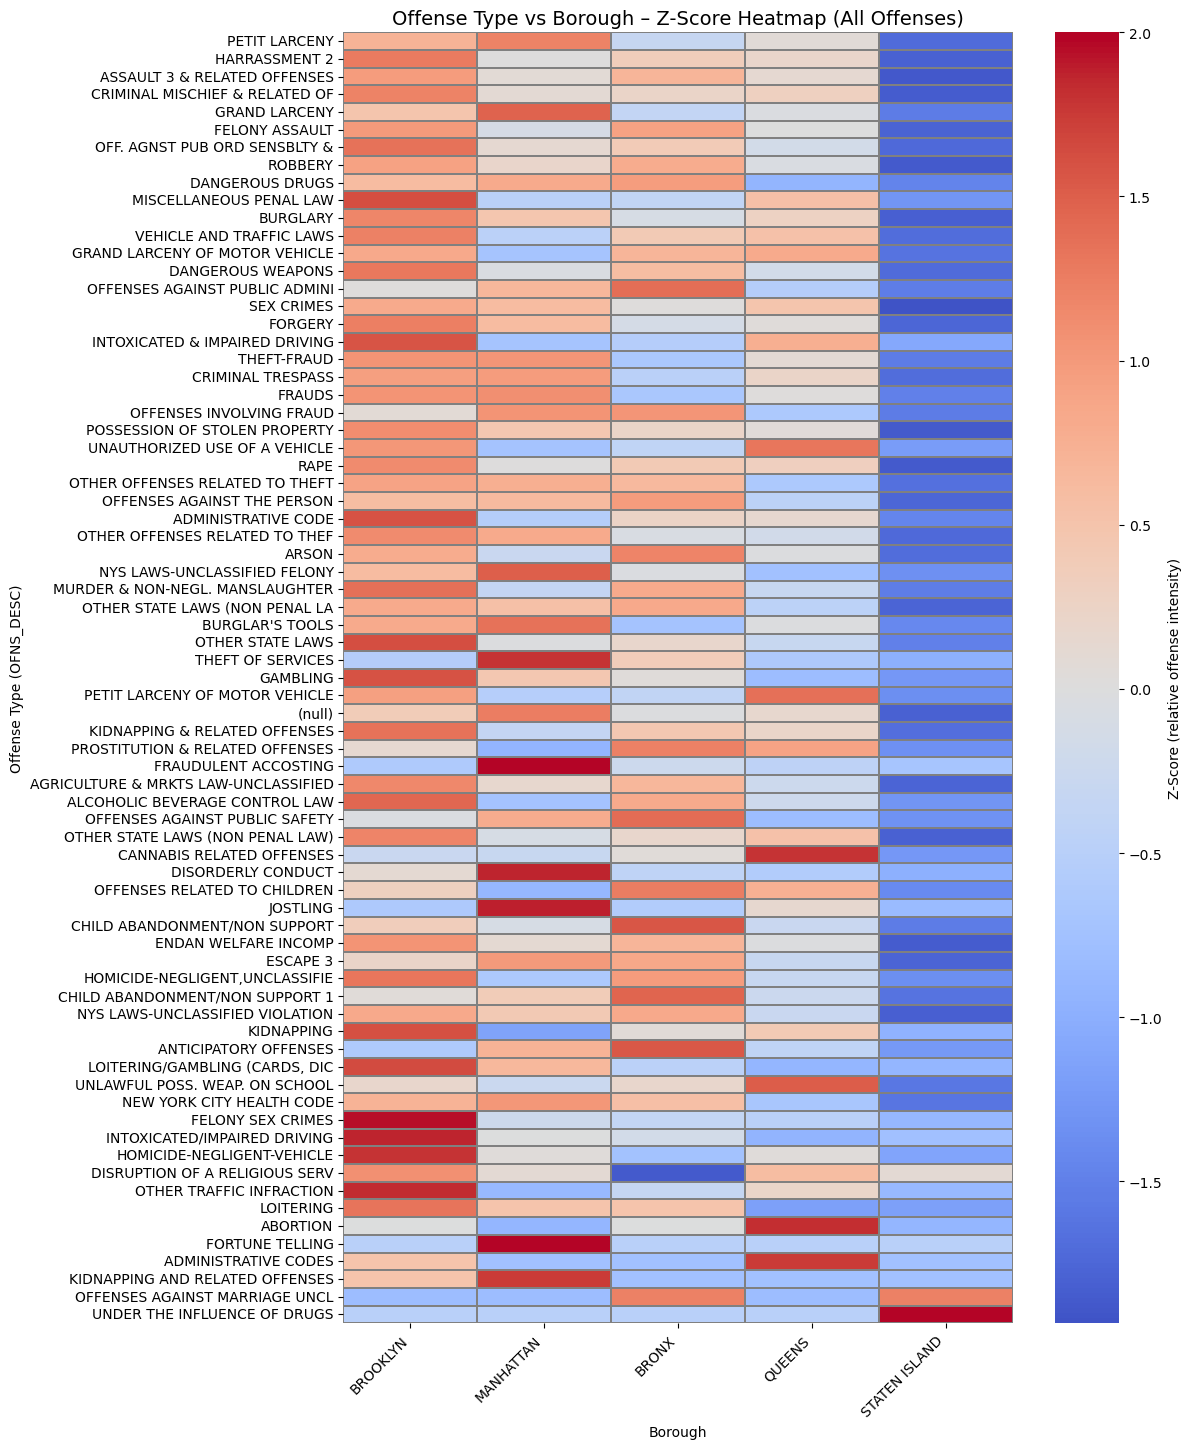

In [40]:
# =========================================================
# 1. Prepare data
# =========================================================

# Start from crime dataframe
df = crime.copy()

# Drop UNKNOWN boroughs if present
if 'BORO_NM_IMPUTED' in df.columns:
    df = df[df['BORO_NM_IMPUTED'] != 'UNKNOWN']
    boro_col = 'BORO_NM_IMPUTED'
else:
    boro_col = 'BORO_NM'
    df = df[df[boro_col] != '(null)']

# Keep needed columns
df = df[['OFNS_DESC', boro_col]].dropna()

print("Total rows used:", len(df))

# =========================================================
# 2. Build OFFENSE × BOROUGH matrix (all offenses)
# =========================================================

heat = pd.crosstab(
    df['OFNS_DESC'],
    df[boro_col]
)

# Sort rows (offenses) by total volume
row_order = heat.sum(axis=1).sort_values(ascending=False).index

# Sort columns (boroughs) by total volume
col_order = heat.sum(axis=0).sort_values(ascending=False).index

heat_sorted = heat.loc[row_order, col_order]

# =========================================================
# 3. Z-SCORE TRANSFORMATION
# =========================================================
# z-score per offense (row):
# z = (value - row_mean) / row_std

heat_z = heat_sorted.apply(
    lambda row: (row - row.mean()) / (row.std(ddof=0) if row.std(ddof=0) != 0 else 1),
    axis=1
)

# =========================================================
# 4. Plot the heatmap
# =========================================================

plt.figure(figsize=(12, max(8, len(heat_z) * 0.2)))  # dynamic height

sns.heatmap(
    heat_z,
    cmap="coolwarm",           # classic z-score palette
    center=0,                  # 0 becomes white
    linewidths=0.2,
    linecolor="gray",
    cbar_kws={'label': 'Z-Score (relative offense intensity)'}
)

plt.title("Offense Type vs Borough – Z-Score Heatmap (All Offenses)", fontsize=14)
plt.xlabel("Borough")
plt.ylabel("Offense Type (OFNS_DESC)")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Rows used for Sankey: 4455436


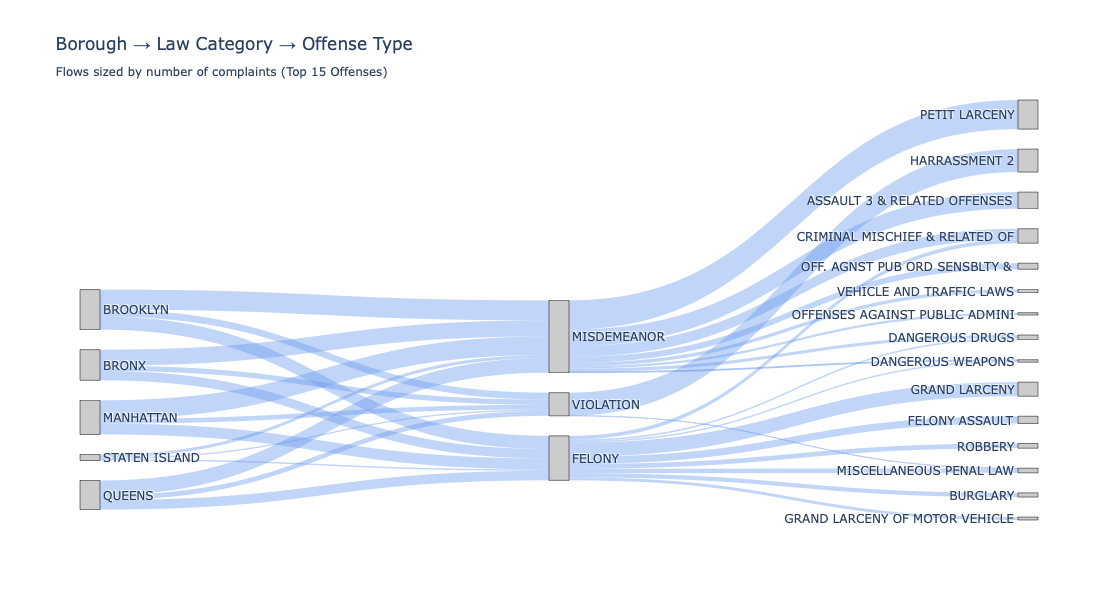

In [41]:
# =========================================================
# 1. Prep data
# =========================================================

df = crime.copy()

# Use imputed boroughs and remove UNKNOWN
if 'BORO_NM_IMPUTED' in df.columns:
    df = df[df['BORO_NM_IMPUTED'] != 'UNKNOWN']
else:
    df = df[df['BORO_NM'] != '(null)']
    df = df.rename(columns={'BORO_NM': 'BORO_NM_IMPUTED'})

# Keep needed columns and drop missing
df = df[['BORO_NM_IMPUTED', 'LAW_CAT_CD', 'OFNS_DESC']].dropna()

# Restrict to top N offenses overall so the diagram stays readable
TOP_N_OFFENSES = 15
top_offenses = df['OFNS_DESC'].value_counts().head(TOP_N_OFFENSES).index
df = df[df['OFNS_DESC'].isin(top_offenses)]

print("Rows used for Sankey:", len(df))

# =========================================================
# 2. Build node list
# =========================================================

# Unique labels for each level
boroughs = list(df['BORO_NM_IMPUTED'].unique())
law_cats = list(df['LAW_CAT_CD'].unique())
offenses = list(top_offenses)

# Make sure law categories have a nice order
law_order = ['FELONY', 'MISDEMEANOR', 'VIOLATION']
law_cats_sorted = [lc for lc in law_order if lc in law_cats] + [lc for lc in law_cats if lc not in law_order]

# Node labels in order: boroughs, law categories, offenses
labels = boroughs + law_cats_sorted + offenses

# Map each label to an index
label_to_idx = {label: i for i, label in enumerate(labels)}

# =========================================================
# 3. Build links: Borough -> Law Category
# =========================================================

links_source = []
links_target = []
links_value  = []

# Borough -> Law category
flow_boro_law = (
    df
    .groupby(['BORO_NM_IMPUTED', 'LAW_CAT_CD'])
    .size()
    .reset_index(name='count')
)

for _, row in flow_boro_law.iterrows():
    boro = row['BORO_NM_IMPUTED']
    law = row['LAW_CAT_CD']
    cnt  = row['count']

    if law not in law_cats_sorted:
        continue

    src = label_to_idx[boro]
    tgt = label_to_idx[law]
    links_source.append(src)
    links_target.append(tgt)
    links_value.append(cnt)

# =========================================================
# 4. Build links: Law Category -> Offense
# =========================================================

flow_law_off = (
    df
    .groupby(['LAW_CAT_CD', 'OFNS_DESC'])
    .size()
    .reset_index(name='count')
)

for _, row in flow_law_off.iterrows():
    law = row['LAW_CAT_CD']
    off = row['OFNS_DESC']
    cnt = row['count']

    if law not in law_cats_sorted or off not in offenses:
        continue

    src = label_to_idx[law]
    tgt = label_to_idx[off]
    links_source.append(src)
    links_target.append(tgt)
    links_value.append(cnt)

# =========================================================
# 5. Create Sankey diagram
# =========================================================

fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
        color="rgba(0,0,0,0.2)"  # semi-transparent gray nodes
    ),
    link=dict(
        source=links_source,
        target=links_target,
        value=links_value,
        color="rgba(100,149,237,0.4)"  # semi-transparent cornflower blue
    )
)])

fig.update_layout(
    title_text="Borough → Law Category → Offense Type<br><sub>Flows sized by number of complaints (Top 15 Offenses)</sub>",
    font=dict(size=12),
    height=600
)

fig.show()

In [42]:
# =========================================================
# 1. Prep data
# =========================================================

df = crime.copy()

# Use imputed boroughs and remove UNKNOWN
if 'BORO_NM_IMPUTED' in df.columns:
    df = df[df['BORO_NM_IMPUTED'] != 'UNKNOWN']
else:
    df = df[df['BORO_NM'] != '(null)']
    df = df.rename(columns={'BORO_NM': 'BORO_NM_IMPUTED'})

# Keep needed columns and drop missing
df = df[['BORO_NM_IMPUTED', 'LAW_CAT_CD', 'OFNS_DESC']].dropna()

# Restrict to the top 15 offenses
TOP_N_OFFENSES = 15
top_offenses = df['OFNS_DESC'].value_counts().head(TOP_N_OFFENSES).index
df = df[df['OFNS_DESC'].isin(top_offenses)]

# =========================================================
# 2. Define node groups
# =========================================================

boroughs = list(df['BORO_NM_IMPUTED'].unique())

# ordered law categories
law_order = ['FELONY', 'MISDEMEANOR', 'VIOLATION']
law_cats_sorted = [lc for lc in law_order if lc in df['LAW_CAT_CD'].unique()]

offenses = list(top_offenses)

labels = boroughs + law_cats_sorted + offenses
label_to_idx = {label: i for i, label in enumerate(labels)}

# =========================================================
# 3. Custom Colors
# =========================================================

# Borough colors (you can change any of these!)
borough_colors = {
    'MANHATTAN':      "#1f77b4",  # blue
    'BROOKLYN':       "#ff7f0e",  # orange
    'BRONX':          "#2ca02c",  # green
    'QUEENS':         "#d62728",  # red
    'STATEN ISLAND':  "#9467bd"   # purple
}

# Law category colors
law_colors = {
    'FELONY':       "rgba(150,150,150,0.6)", 
    'MISDEMEANOR':  "rgba(180,180,180,0.6)", 
    'VIOLATION':    "rgba(200,200,200,0.6)"
}

# Offense colors (uniform softer tone)
offense_color = "rgba(135,206,250,0.5)"    # light sky blue

# Create final node colors in the correct order
node_colors = []

for label in labels:
    if label in borough_colors:
        node_colors.append(borough_colors[label])
    elif label in law_colors:
        node_colors.append(law_colors[label])
    else:
        node_colors.append(offense_color)

# =========================================================
# 4. Build links
# =========================================================

links_source = []
links_target = []
links_value  = []
links_color  = []   # <-- NEW (colored based on source node)

# Borough -> Law category
flows_boro_law = (
    df.groupby(['BORO_NM_IMPUTED', 'LAW_CAT_CD'])
      .size()
      .reset_index(name='count')
)

for _, row in flows_boro_law.iterrows():
    boro = row['BORO_NM_IMPUTED']
    law = row['LAW_CAT_CD']
    cnt = row['count']

    src = label_to_idx[boro]
    tgt = label_to_idx[law]

    links_source.append(src)
    links_target.append(tgt)
    links_value.append(cnt)

    links_color.append(borough_colors[boro])   # link inherits borough color

# Law category -> Offense
flows_law_off = (
    df.groupby(['LAW_CAT_CD', 'OFNS_DESC'])
      .size()
      .reset_index(name='count')
)

for _, row in flows_law_off.iterrows():
    law = row['LAW_CAT_CD']
    off = row['OFNS_DESC']
    cnt = row['count']

    src = label_to_idx[law]
    tgt = label_to_idx[off]

    links_source.append(src)
    links_target.append(tgt)
    links_value.append(cnt)

    # use law color for these links
    links_color.append(law_colors[law])

# =========================================================
# 5. Render Sankey
# =========================================================

fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
        color=node_colors
    ),
    link=dict(
        source=links_source,
        target=links_target,
        value=links_value,
        color=links_color  # <-- colored links
    )
)])

fig.update_layout(
    title_text="Crime Flow: Borough → Law Category → Offense<br><sub>Colored by Borough & Severity</sub>",
    font_size=12,
    height=650
)

fig.show()

In [43]:
# =========================================================
# 1. Prep data
# =========================================================

df = crime.copy()

# Use imputed boroughs and remove UNKNOWN
if 'BORO_NM_IMPUTED' in df.columns:
    df = df[df['BORO_NM_IMPUTED'] != 'UNKNOWN']
else:
    df = df[df['BORO_NM'] != '(null)']
    df = df.rename(columns={'BORO_NM': 'BORO_NM_IMPUTED'})

# Keep needed columns and drop missing
df = df[['BORO_NM_IMPUTED', 'LAW_CAT_CD', 'OFNS_DESC']].dropna()

# Restrict to the top N offenses for readability
TOP_N_OFFENSES = 15
top_offenses = df['OFNS_DESC'].value_counts().head(TOP_N_OFFENSES).index
df = df[df['OFNS_DESC'].isin(top_offenses)]

# Standardize law category order where possible
law_order = ['FELONY', 'MISDEMEANOR', 'VIOLATION']
df = df[df['LAW_CAT_CD'].isin(law_order)]

# =========================================================
# 2. Define nodes: Borough, Borough+Law, Offense
# =========================================================

boroughs = sorted(df['BORO_NM_IMPUTED'].unique())
offenses = list(top_offenses)

# Create middle layer: "BOROUGH - LAW_CAT"
df['BORO_LAW'] = df['BORO_NM_IMPUTED'] + ' - ' + df['LAW_CAT_CD']
boro_law_nodes = sorted(df['BORO_LAW'].unique())

# Node labels in order: boroughs, boro+law, offenses
labels = boroughs + boro_law_nodes + offenses
label_to_idx = {label: i for i, label in enumerate(labels)}

# =========================================================
# 3. Define base borough colors
# =========================================================

borough_colors = {
    'MANHATTAN':      "#1f77b4",  # blue
    'BROOKLYN':       "#ff7f0e",  # orange
    'BRONX':          "#2ca02c",  # green
    'QUEENS':         "#d62728",  # red
    'STATEN ISLAND':  "#9467bd"   # purple
}

# Helper to slightly lighten or desaturate a hex color
def adjust_alpha(hex_color, alpha=0.6):
    # convert "#RRGGBB" to rgba string with given alpha
    hex_color = hex_color.lstrip('#')
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f'rgba({r},{g},{b},{alpha})'

# =========================================================
# 4. Node colors
#    - Borough nodes: solid borough colors
#    - Borough+Law nodes:
#         FELONY      -> same borough color but strong alpha
#         MISDEMEANOR -> medium alpha
#         VIOLATION   -> light alpha (so still same hue but "lighter")
#    - Offense nodes: neutral light gray
# =========================================================

node_colors = []

for label in labels:
    if label in borough_colors:  # pure borough
        node_colors.append(borough_colors[label])
    elif " - " in label:         # BOROUGH - LAW_CAT
        boro, law = label.split(" - ", 1)
        base = borough_colors.get(boro, "#888888")
        if law == 'FELONY':
            node_colors.append(adjust_alpha(base, 0.95))
        elif law == 'MISDEMEANOR':
            node_colors.append(adjust_alpha(base, 0.75))
        elif law == 'VIOLATION':
            node_colors.append(adjust_alpha(base, 0.5))
        else:
            node_colors.append(adjust_alpha(base, 0.7))
    else:
        # Offense nodes -> neutral gray
        node_colors.append("rgba(200,200,200,0.8)")

# =========================================================
# 5. Build links
# =========================================================

links_source = []
links_target = []
links_value  = []
links_color  = []

# 5a. Borough -> Borough+Law
flow_boro_borolaw = (
    df.groupby(['BORO_NM_IMPUTED', 'BORO_LAW'])
      .size()
      .reset_index(name='count')
)

for _, row in flow_boro_borolaw.iterrows():
    boro = row['BORO_NM_IMPUTED']
    boro_law = row['BORO_LAW']
    cnt = row['count']

    src = label_to_idx[boro]
    tgt = label_to_idx[boro_law]

    links_source.append(src)
    links_target.append(tgt)
    links_value.append(cnt)

    # Link color = solid borough color
    links_color.append(adjust_alpha(borough_colors.get(boro, "#888888"), 0.8))

# 5b. Borough+Law -> Offense
flow_borolaw_off = (
    df.groupby(['BORO_LAW', 'OFNS_DESC'])
      .size()
      .reset_index(name='count')
)

for _, row in flow_borolaw_off.iterrows():
    boro_law = row['BORO_LAW']
    off = row['OFNS_DESC']
    cnt = row['count']

    src = label_to_idx[boro_law]
    tgt = label_to_idx[off]

    links_source.append(src)
    links_target.append(tgt)
    links_value.append(cnt)

    # Link color = same as the BORO+LAW node (so carries borough hue & law intensity)
    src_color = node_colors[src]
    links_color.append(src_color)

# =========================================================
# 6. Build the Sankey figure
# =========================================================

fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
        color=node_colors
    ),
    link=dict(
        source=links_source,
        target=links_target,
        value=links_value,
        color=links_color
    )
)])

fig.update_layout(
    title_text=(
        "Crime Flow: Borough → Borough + Law Category → Offense<br>"
        "<sub>Violations/Felonies/Misdemeanors keep the borough's hue "
        "with lighter shades for less severe categories.</sub>"
    ),
    font_size=12,
    height=700
)

fig.show()

In [44]:
# =========================================================
# 1. Prep data
# =========================================================

df = crime.copy()

# Use imputed boroughs and remove UNKNOWN
if 'BORO_NM_IMPUTED' in df.columns:
    df = df[df['BORO_NM_IMPUTED'] != 'UNKNOWN']
else:
    df = df[df['BORO_NM'] != '(null)']
    df = df.rename(columns={'BORO_NM': 'BORO_NM_IMPUTED'})

# Keep needed columns and drop missing
df = df[['BORO_NM_IMPUTED', 'LAW_CAT_CD', 'OFNS_DESC']].dropna()

# Restrict to the top N offenses for readability
TOP_N_OFFENSES = 15
top_offenses = df['OFNS_DESC'].value_counts().head(TOP_N_OFFENSES).index
df = df[df['OFNS_DESC'].isin(top_offenses)]

# Only standard law categories
law_order = ['FELONY', 'MISDEMEANOR', 'VIOLATION']
df = df[df['LAW_CAT_CD'].isin(law_order)]

# =========================================================
# 2. Define nodes: Borough, Borough+Law, Offense
# =========================================================

# Explicit borough order
boroughs = ['MANHATTAN', 'BROOKLYN', 'BRONX', 'QUEENS', 'STATEN ISLAND']
boroughs = [b for b in boroughs if b in df['BORO_NM_IMPUTED'].unique()]

# Middle layer: BORO_LAW
df['BORO_LAW'] = df['BORO_NM_IMPUTED'] + ' - ' + df['LAW_CAT_CD']

# Build BORO_LAW nodes in grouped severity order per borough
unique_boro_law = set(df['BORO_LAW'].unique())
boro_law_nodes = []
for boro in boroughs:
    for law in law_order:  # seriousness order: FELONY -> MISD -> VIOLATION
        combo = f"{boro} - {law}"
        if combo in unique_boro_law:
            boro_law_nodes.append(combo)

offenses = list(top_offenses)

# Final label order: boroughs, then grouped boro+law, then offenses
labels = boroughs + boro_law_nodes + offenses
label_to_idx = {label: i for i, label in enumerate(labels)}

# =========================================================
# 3. Colors
# =========================================================

borough_colors = {
    'MANHATTAN':      "#1f77b4",  # blue
    'BROOKLYN':       "#ff7f0e",  # orange
    'BRONX':          "#2ca02c",  # green
    'QUEENS':         "#d62728",  # red
    'STATEN ISLAND':  "#9467bd"   # purple
}

def adjust_alpha(hex_color, alpha=0.6):
    hex_color = hex_color.lstrip('#')
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f'rgba({r},{g},{b},{alpha})'

node_colors = []
for label in labels:
    if label in borough_colors:  # pure borough
        node_colors.append(borough_colors[label])
    elif " - " in label:         # BORO_LAW node
        boro, law = label.split(" - ", 1)
        base = borough_colors.get(boro, "#888888")
        if law == 'FELONY':
            node_colors.append(adjust_alpha(base, 0.95))
        elif law == 'MISDEMEANOR':
            node_colors.append(adjust_alpha(base, 0.75))
        elif law == 'VIOLATION':
            node_colors.append(adjust_alpha(base, 0.50))
        else:
            node_colors.append(adjust_alpha(base, 0.70))
    else:
        # Offenses – neutral gray
        node_colors.append("rgba(200,200,200,0.85)")

# =========================================================
# 4. Links
# =========================================================

links_source, links_target, links_value, links_color = [], [], [], []

# Borough -> BORO_LAW
flow_boro_borolaw = (
    df.groupby(['BORO_NM_IMPUTED', 'BORO_LAW'])
      .size()
      .reset_index(name='count')
)

for _, row in flow_boro_borolaw.iterrows():
    boro = row['BORO_NM_IMPUTED']
    boro_law = row['BORO_LAW']
    cnt = row['count']

    src = label_to_idx[boro]
    tgt = label_to_idx[boro_law]

    links_source.append(src)
    links_target.append(tgt)
    links_value.append(cnt)
    links_color.append(adjust_alpha(borough_colors.get(boro, "#888888"), 0.8))

# BORO_LAW -> Offense
flow_borolaw_off = (
    df.groupby(['BORO_LAW', 'OFNS_DESC'])
      .size()
      .reset_index(name='count')
)

for _, row in flow_borolaw_off.iterrows():
    boro_law = row['BORO_LAW']
    off = row['OFNS_DESC']
    cnt = row['count']

    src = label_to_idx[boro_law]
    tgt = label_to_idx[off]

    links_source.append(src)
    links_target.append(tgt)
    links_value.append(cnt)

    # link color = color of BORO_LAW node
    src_color = node_colors[src]
    links_color.append(src_color)

# =========================================================
# 5. Explicit node positions (x, y) so order is respected
# =========================================================

n_boro = len(boroughs)
n_borolaw = len(boro_law_nodes)
n_off = len(offenses)

# x positions: 3 columns
x_boro    = [0.0] * n_boro
x_borolaw = [0.5] * n_borolaw
x_off     = [1.0] * n_off
node_x = x_boro + x_borolaw + x_off

# y positions: equally spaced within each column in the SAME order as labels
y_boro = list(np.linspace(0.05, 0.95, n_boro))
y_borolaw = list(np.linspace(0.05, 0.95, n_borolaw))
y_off = list(np.linspace(0.05, 0.95, n_off))
node_y = y_boro + y_borolaw + y_off

# =========================================================
# 6. Build Sankey with fixed arrangement
# =========================================================

fig = go.Figure(data=[go.Sankey(
    arrangement="fixed",      # <--- IMPORTANT
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
        color=node_colors,
        x=node_x,
        y=node_y
    ),
    link=dict(
        source=links_source,
        target=links_target,
        value=links_value,
        color=links_color
    )
)])

fig.update_layout(
    title_text=(
        "Crime Flow: Borough → Borough+Severity → Offense<br>"
        "<sub>Middle nodes grouped by Borough (FELONY → MISDEMEANOR → VIOLATION)</sub>"
    ),
    font_size=12,
    height=720
)

fig.show()

In [45]:
# ============================
# 1. Prep data
# ============================
df = crime.copy()

# Use imputed boroughs and drop UNKNOWN
if 'BORO_NM_IMPUTED' in df.columns:
    df = df[df['BORO_NM_IMPUTED'] != 'UNKNOWN']
else:
    df = df[df['BORO_NM'] != '(null)']
    df = df.rename(columns={'BORO_NM': 'BORO_NM_IMPUTED'})

# Keep relevant columns and drop missing
df = df[['BORO_NM_IMPUTED', 'LAW_CAT_CD', 'OFNS_DESC']].dropna()

# Optional: limit to top N offenses overall for readability
TOP_N_OFFENSES = 25
top_offenses = df['OFNS_DESC'].value_counts().head(TOP_N_OFFENSES).index
df = df[df['OFNS_DESC'].isin(top_offenses)]

# Aggregate counts
treemap_df = (
    df.groupby(['BORO_NM_IMPUTED', 'LAW_CAT_CD', 'OFNS_DESC'])
      .size()
      .reset_index(name='count')
)

treemap_df.head()

# ============================
# 2. Treemap
# ============================
fig = px.treemap(
    treemap_df,
    path=['BORO_NM_IMPUTED', 'LAW_CAT_CD', 'OFNS_DESC'],
    values='count',
    color='LAW_CAT_CD',
    color_discrete_map={
        'FELONY': '#d62728',       # red
        'MISDEMEANOR': '#ff7f0e',  # orange
        'VIOLATION': '#1f77b4'     # blue
    },
    title="NYC Crime Composition<br><sup>Borough → Law Category → Offense (Top 25 Offenses)</sup>",
)

fig.update_layout(
    margin=dict(t=60, l=0, r=0, b=0),
)

fig.show()

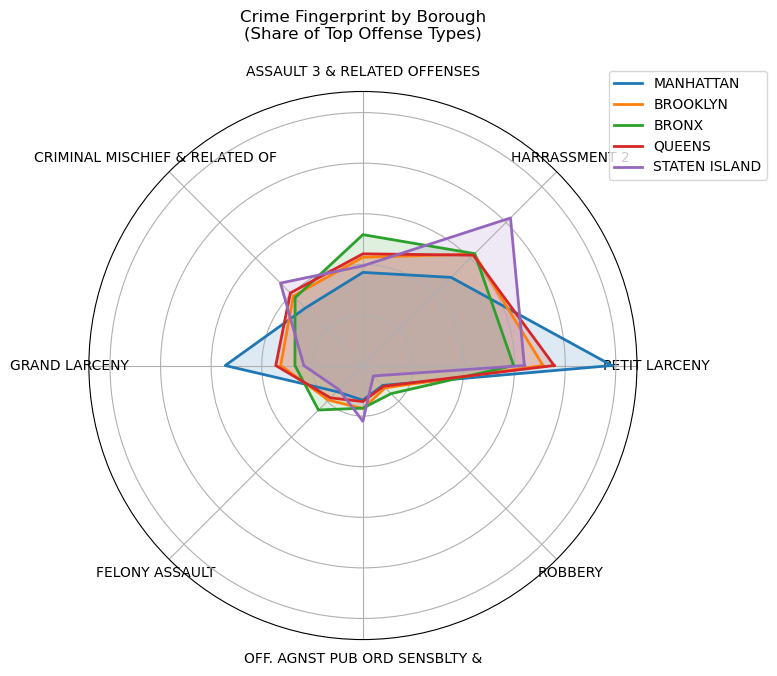

In [46]:
# ==============================
# 1. Prep data
# ==============================
df = crime.copy()

# Use imputed boroughs and drop UNKNOWN
if 'BORO_NM_IMPUTED' in df.columns:
    df = df[df['BORO_NM_IMPUTED'] != 'UNKNOWN']
else:
    df = df[df['BORO_NM'] != '(null)']
    df = df.rename(columns={'BORO_NM': 'BORO_NM_IMPUTED'})

df = df[['BORO_NM_IMPUTED', 'OFNS_DESC']].dropna()

# Keep only the 5 main boroughs in a fixed order
boroughs = ['MANHATTAN', 'BROOKLYN', 'BRONX', 'QUEENS', 'STATEN ISLAND']
boroughs = [b for b in boroughs if b in df['BORO_NM_IMPUTED'].unique()]

# ==============================
# 2. Pick offense axes (top N overall)
# ==============================
TOP_N = 8
top_offenses = df['OFNS_DESC'].value_counts().head(TOP_N).index.tolist()

# For clarity you can shorten long labels if needed:
offense_labels = list(top_offenses)

# ==============================
# 3. Build borough × offense share table
#     (each row sums to 1 across offenses + "Other")
# ==============================
# First count offenses by borough
ct = (
    df[df['OFNS_DESC'].isin(top_offenses)]
    .groupby(['BORO_NM_IMPUTED', 'OFNS_DESC'])
    .size()
    .unstack(fill_value=0)
)

# Ensure we have all top offenses as columns
ct = ct.reindex(columns=top_offenses, fill_value=0)

# Total complaints per borough (all offenses)
boro_totals = df.groupby('BORO_NM_IMPUTED').size()

# Compute share for each offense axis (within borough)
shares = ct.div(boro_totals, axis=0).reindex(boroughs)

shares

# ==============================
# 4. Radar chart (multi-borough overlay)
# ==============================

# Number of axes
N = len(top_offenses)

# Angles for each axis (in radians)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
angles = np.concatenate([angles, [angles[0]]])  # close the loop

# Prepare figure
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Color palette for boroughs
colors = {
    'MANHATTAN':      "#1f77b4",
    'BROOKLYN':       "#ff7f0e",
    'BRONX':          "#2ca02c",
    'QUEENS':         "#d62728",
    'STATEN ISLAND':  "#9467bd"
}

# Plot each borough
for boro in boroughs:
    if boro not in shares.index:
        continue
    vals = shares.loc[boro, offense_labels].values
    vals = np.concatenate([vals, [vals[0]]])  # close the polygon

    ax.plot(angles, vals,
            label=boro,
            linewidth=2,
            color=colors.get(boro, None))
    ax.fill(angles, vals,
            alpha=0.15,
            color=colors.get(boro, None))

# Axis labels (offense names)
ax.set_xticks(np.linspace(0, 2 * np.pi, N, endpoint=False))
ax.set_xticklabels(offense_labels, fontsize=10)

# Radial label formatting (percentages)
ax.set_yticklabels([])
ax.set_ylim(0, shares.values.max() * 1.1)

plt.title("Crime Fingerprint by Borough\n(Share of Top Offense Types)", y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.05))
plt.tight_layout()
plt.show()

Number of offense types: 73


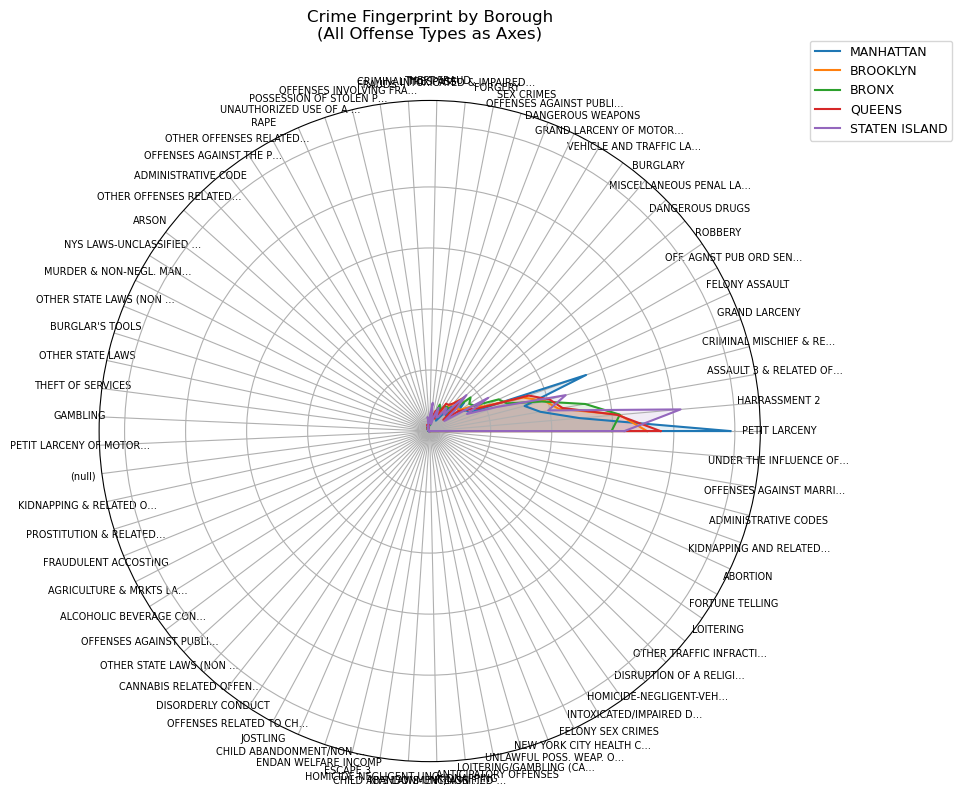

In [47]:
# ============================================
# 1. Prep data
# ============================================
df = crime.copy()

# Use imputed boroughs and drop UNKNOWN
if 'BORO_NM_IMPUTED' in df.columns:
    df = df[df['BORO_NM_IMPUTED'] != 'UNKNOWN']
else:
    df = df[df['BORO_NM'] != '(null)']
    df = df.rename(columns={'BORO_NM': 'BORO_NM_IMPUTED'})

df = df[['BORO_NM_IMPUTED', 'OFNS_DESC']].dropna()

# Fixed borough order (keep only those present)
boroughs = ['MANHATTAN', 'BROOKLYN', 'BRONX', 'QUEENS', 'STATEN ISLAND']
boroughs = [b for b in boroughs if b in df['BORO_NM_IMPUTED'].unique()]

# ============================================
# 2. Use ALL offenses as axes
#    (sorted by overall frequency)
# ============================================
offense_labels = df['OFNS_DESC'].value_counts().index.tolist()   # ALL offenses
N = len(offense_labels)
print(f"Number of offense types: {N}")

# Optional: shorten labels for plotting (first 22 chars)
short_labels = [lbl[:22] + ('…' if len(lbl) > 22 else '') for lbl in offense_labels]

# ============================================
# 3. Build borough × offense shares
# ============================================
# Counts of each offense per borough
ct = (
    df.groupby(['BORO_NM_IMPUTED', 'OFNS_DESC'])
      .size()
      .unstack(fill_value=0)
)

# Ensure all offenses are present as columns in the right order
ct = ct.reindex(columns=offense_labels, fill_value=0)

# Total complaints per borough (all offenses)
boro_totals = df.groupby('BORO_NM_IMPUTED').size()

# Share of each offense within borough (row-wise percentages)
shares = ct.div(boro_totals, axis=0).reindex(boroughs)

# ============================================
# 4. Radar chart – ALL offenses
# ============================================
# Angles for each axis
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
angles = np.concatenate([angles, [angles[0]]])  # close loop

fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

# Colors for boroughs
colors = {
    'MANHATTAN':      "#1f77b4",
    'BROOKLYN':       "#ff7f0e",
    'BRONX':          "#2ca02c",
    'QUEENS':         "#d62728",
    'STATEN ISLAND':  "#9467bd"
}

for boro in boroughs:
    if boro not in shares.index:
        continue
    vals = shares.loc[boro, offense_labels].values
    vals = np.concatenate([vals, [vals[0]]])

    ax.plot(angles, vals,
            label=boro,
            linewidth=1.5,
            color=colors.get(boro, None))
    ax.fill(angles, vals,
            alpha=0.12,
            color=colors.get(boro, None))

# Axis labels (shortened offense names)
ax.set_xticks(np.linspace(0, 2 * np.pi, N, endpoint=False))
ax.set_xticklabels(short_labels, fontsize=7)

# Hide radial tick labels, just keep grid
ax.set_yticklabels([])
ax.set_ylim(0, shares.values.max() * 1.1)

plt.title("Crime Fingerprint by Borough\n(All Offense Types as Axes)", y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

In [48]:
# ============================
# 1. Prep data
# ============================
df = crime.copy()

# Use imputed boroughs and drop UNKNOWN
if 'BORO_NM_IMPUTED' in df.columns:
    df = df[df['BORO_NM_IMPUTED'] != 'UNKNOWN']
else:
    df = df[df['BORO_NM'] != '(null)']
    df = df.rename(columns={'BORO_NM': 'BORO_NM_IMPUTED'})

# Keep only what we need
df = df[['BORO_NM_IMPUTED', 'LAW_CAT_CD']].dropna()

# Filter to the standard 3 law categories just in case
valid_law = ['FELONY', 'MISDEMEANOR', 'VIOLATION']
df = df[df['LAW_CAT_CD'].isin(valid_law)]

# ============================
# 2. Borough x Law counts and shares
# ============================
ct = (
    df.groupby(['BORO_NM_IMPUTED', 'LAW_CAT_CD'])
      .size()
      .unstack(fill_value=0)
)

# Ensure all three categories exist as columns
ct = ct.reindex(columns=valid_law, fill_value=0)

# Total complaints per borough
ct['total'] = ct.sum(axis=1)

# Convert to *shares* (each row sums to 1 across the three corners)
for col in valid_law:
    ct[col] = ct[col] / ct['total']

ct = ct.reset_index()  # bring BORO_NM_IMPUTED back as a column
ct


# ============================
# 3. Ternary (triangle) plot
# ============================

# Custom colors for boroughs (same as before, optional)
borough_colors = {
    'MANHATTAN':      "#1f77b4",
    'BROOKLYN':       "#ff7f0e",
    'BRONX':          "#2ca02c",
    'QUEENS':         "#d62728",
    'STATEN ISLAND':  "#9467bd"
}

fig = px.scatter_ternary(
    ct,
    a='FELONY',
    b='MISDEMEANOR',
    c='VIOLATION',
    color='BORO_NM_IMPUTED',
    size='total',
    hover_name='BORO_NM_IMPUTED',
    hover_data={'total': True, 'FELONY': ':.2f', 'MISDEMEANOR': ':.2f', 'VIOLATION': ':.2f'},
    color_discrete_map=borough_colors,
    size_max=40,
    title="Crime Severity Triangle by Borough<br><sup>Position = share of Felony / Misdemeanor / Violation, Size = total complaints</sup>",
)

fig.update_layout(
    ternary=dict(
        sum=1,
        aaxis=dict(title='Felony share'),
        baxis=dict(title='Misdemeanor share'),
        caxis=dict(title='Violation share')
    ),
    legend_title_text="Borough"
)

fig.show()

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# =====================================
# 1. Prep data (same as ternary setup)
# =====================================
df = crime.copy()

# Use imputed boroughs and drop UNKNOWN
if 'BORO_NM_IMPUTED' in df.columns:
    df = df[df['BORO_NM_IMPUTED'] != 'UNKNOWN']
else:
    df = df[df['BORO_NM'] != '(null)']
    df = df.rename(columns={'BORO_NM': 'BORO_NM_IMPUTED'})

df = df[['BORO_NM_IMPUTED', 'LAW_CAT_CD']].dropna()

valid_law = ['FELONY', 'MISDEMEANOR', 'VIOLATION']
df = df[df['LAW_CAT_CD'].isin(valid_law)]

# Count by borough x law
ct = (
    df.groupby(['BORO_NM_IMPUTED', 'LAW_CAT_CD'])
      .size()
      .unstack(fill_value=0)
)

# Ensure all 3 columns exist
ct = ct.reindex(columns=valid_law, fill_value=0)

# Total complaints per borough
ct['total'] = ct.sum(axis=1)

# Shares
for col in valid_law:
    ct[col] = ct[col] / ct['total']

ct = ct.reset_index()  # BORO_NM_IMPUTED back as col
ct

# =====================================
# 2. Map shares → 2D triangle coords
#    Vertices (equilateral):
#    F (Felony)     = (0, 0)
#    M (Misdemeanor)= (1, 0)
#    V (Violation)  = (0.5, sqrt(3)/2)
#    Point = a*F + b*M + c*V (barycentric)
# =====================================
import math

def ternary_to_cartesian(a, b, c):
    # a = Felony, b = Misdemeanor, c = Violation; assume a+b+c=1
    F = np.array([0.0, 0.0])
    M = np.array([1.0, 0.0])
    V = np.array([0.5, math.sqrt(3)/2])
    p = a * F + b * M + c * V
    return p[0], p[1]

xs, ys, zs = [], [], []
names = []

for _, row in ct.iterrows():
    a = row['FELONY']
    b = row['MISDEMEANOR']
    c = row['VIOLATION']
    x, y = ternary_to_cartesian(a, b, c)
    z = row['total']
    xs.append(x)
    ys.append(y)
    zs.append(z)
    names.append(row['BORO_NM_IMPUTED'])

xs = np.array(xs)
ys = np.array(ys)
zs = np.array(zs)


# =====================================
# 3. Build 3D triangle base (mesh) + borough points
# =====================================

# Triangle vertices (same as above, at z=0)
F = (0.0, 0.0, 0.0)
M = (1.0, 0.0, 0.0)
V = (0.5, math.sqrt(3)/2, 0.0)

mesh_x = [F[0], M[0], V[0]]
mesh_y = [F[1], M[1], V[1]]
mesh_z = [F[2], M[2], V[2]]

fig = go.Figure()

# Base triangle (transparent)
fig.add_trace(go.Mesh3d(
    x=mesh_x,
    y=mesh_y,
    z=mesh_z,
    color='lightgray',
    opacity=0.2,
    i=[0], j=[1], k=[2]  # one triangular face
))

# Borough points
borough_colors = {
    'MANHATTAN':      "#1f77b4",
    'BROOKLYN':       "#ff7f0e",
    'BRONX':          "#2ca02c",
    'QUEENS':         "#d62728",
    'STATEN ISLAND':  "#9467bd"
}

colors = [borough_colors.get(n, "#555555") for n in names]

fig.add_trace(go.Scatter3d(
    x=xs,
    y=ys,
    z=zs,
    mode='markers+text',
    marker=dict(
        size=10,
        color=colors,
        opacity=0.9
    ),
    text=names,
    textposition="top center",
    hovertemplate=(
        "Borough: %{text}<br>"
        "Felony share: %{customdata[0]:.2f}<br>"
        "Misd. share: %{customdata[1]:.2f}<br>"
        "Violation share: %{customdata[2]:.2f}<br>"
        "Total complaints: %{customdata[3]:,}<extra></extra>"
    ),
    customdata=np.column_stack([
        ct['FELONY'].values,
        ct['MISDEMEANOR'].values,
        ct['VIOLATION'].values,
        ct['total'].values
    ])
))

# Label triangle corners in 3D
fig.add_trace(go.Scatter3d(
    x=[F[0], M[0], V[0]],
    y=[F[1], M[1], V[1]],
    z=[0, 0, 0],
    mode='text',
    text=['Felony', 'Misdemeanor', 'Violation'],
    textposition="bottom center",
    showlegend=False
))

fig.update_layout(
    title="3D Crime Severity Prism by Borough<br><sup>Base = Felony/Misd/Violation mix, Height = total complaints</sup>",
    scene=dict(
        xaxis_title='',
        yaxis_title='',
        zaxis_title='Total complaints',
        xaxis=dict(showticklabels=False, visible=False),
        yaxis=dict(showticklabels=False, visible=False),
        aspectmode='data'
    ),
    legend_title_text='Borough'
)

fig.show()
ÎÎ

In [ ]:
# =====================================
# 1. Prep data: shares of each law type
# =====================================
df = crime.copy()

# Use imputed boroughs and drop UNKNOWN
if 'BORO_NM_IMPUTED' in df.columns:
    df = df[df['BORO_NM_IMPUTED'] != 'UNKNOWN']
else:
    df = df[df['BORO_NM'] != '(null)']
    df = df.rename(columns={'BORO_NM': 'BORO_NM_IMPUTED'})

df = df[['BORO_NM_IMPUTED', 'LAW_CAT_CD']].dropna()

valid_law = ['FELONY', 'MISDEMEANOR', 'VIOLATION']
df = df[df['LAW_CAT_CD'].isin(valid_law)]

# counts by borough x law
ct = (
    df.groupby(['BORO_NM_IMPUTED', 'LAW_CAT_CD'])
      .size()
      .unstack(fill_value=0)
)

# ensure columns exist
ct = ct.reindex(columns=valid_law, fill_value=0)

# total & shares
ct['total'] = ct.sum(axis=1)
for col in valid_law:
    ct[col] = ct[col] / ct['total']   # share 0–1

# fixed borough order
boroughs = ['MANHATTAN', 'BROOKLYN', 'BRONX', 'QUEENS', 'STATEN ISLAND']
boroughs = [b for b in boroughs if b in ct.index]

shares = ct.loc[boroughs, valid_law]  # rows: boroughs, cols: FELONY/MISD/VIOL

shares

# =====================================
# 2. Triangular radar plot (3-axis radar)
# =====================================

# 3 axes → triangle: angles 0, 120°, 240°
N = 3
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
angles = np.concatenate([angles, [angles[0]]])  # close loop

# scale shares to "0–5" style like your reference (optional)
scale_max = 5
scaled = shares * scale_max

# colors per borough
colors = {
    'MANHATTAN':      "#1f77b4",
    'BROOKLYN':       "#ff7f0e",
    'BRONX':          "#2ca02c",
    'QUEENS':         "#d62728",
    'STATEN ISLAND':  "#9467bd"
}

fig = plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)

# ---- grid: concentric triangles (0–5) ----
levels = 5
for lvl in range(1, levels + 1):
    r = scale_max * lvl / levels
    vals = np.array([r, r, r, r])       # same radius on each axis, close loop
    ax.plot(angles, vals, color='gray', linewidth=0.5)
    ax.fill(angles, vals, color='gray', alpha=0.02)

    ax.text(angles[0], r, str(lvl),
            ha='center', va='bottom', fontsize=8, color='gray')

# ---- one filled triangle per borough ----
for boro in boroughs:
    vals = scaled.loc[boro, valid_law].values
    vals = np.concatenate([vals, [vals[0]]])   # close

    ax.plot(angles, vals,
            linewidth=2,
            label=boro,
            color=colors.get(boro, None))
    ax.fill(angles, vals,
            alpha=0.15,
            color=colors.get(boro, None))

# axis labels at triangle vertices
ax.set_xticks(angles[:-1])
ax.set_xticklabels(['Felony', 'Misdemeanor', 'Violation'], fontsize=10)

# hide radial tick labels (we wrote our own)
ax.set_yticklabels([])
ax.set_ylim(0, scale_max)

plt.title("Crime Severity Triangle by Borough\n(Share of Felony / Misdemeanor / Violation)", y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
scale_max = 4
scaled = shares * scale_max

# Colors per borough (same as before)
colors = {
    'MANHATTAN':      "#1f77b4",
    'BROOKLYN':       "#ff7f0e",
    'BRONX':          "#2ca02c",
    'QUEENS':         "#d62728",
    'STATEN ISLAND':  "#9467bd"
}

# ==============================
# 1. Triangle orientation
# ==============================
# We want: apex up, base horizontal.
# Angles in degrees: Felony (top), Misdemeanor (bottom right), Violation (bottom left)
angles_deg = np.array([90, 330, 210])
angles = np.deg2rad(angles_deg)
angles = np.concatenate([angles, [angles[0]]])  # close loop

fig = plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)

# ==============================
# 2. Concentric triangular grid
# ==============================
levels = 5
for lvl in range(1, levels + 1):
    r = scale_max * lvl / levels
    vals = np.array([r, r, r, r])  # 3 axes + close
    ax.plot(angles, vals, color='gray', linewidth=0.5)
    ax.fill(angles, vals, color='gray', alpha=0.02)

    # numeric labels along one edge (near Felony axis)
    ax.text(
        np.deg2rad(90),  # along top axis
        r,
        f"{lvl}",
        ha="center",
        va="bottom",
        fontsize=8,
        color="gray"
    )

# ==============================
# 3. Borough triangles
# ==============================
for boro in boroughs:
    vals = scaled.loc[boro, valid_law].values
    vals = np.concatenate([vals, [vals[0]]])

    ax.plot(
        angles,
        vals,
        linewidth=2,
        label=boro,
        color=colors.get(boro, None)
    )
    ax.fill(
        angles,
        vals,
        alpha=0.15,
        color=colors.get(boro, None)
    )

# ==============================
# 4. Custom axis labels on circumference
# ==============================

ax.set_xticks([])  # remove default labels
ax.set_yticklabels([])  # hide radial labels
ax.set_ylim(0, scale_max)

axis_names = ['Felony', 'Misdemeanor', 'Violation']

for ang_deg, label in zip(angles_deg, axis_names):
    ang = np.deg2rad(ang_deg)
    r_label = scale_max * 1.07  # a bit outside the outer grid

    # rotation so text is roughly tangent to the circumference
    rotation = ang_deg - 90  # tangent orientation

    ax.text(
        ang,
        r_label,
        label,
        ha="center",
        va="center",
        fontsize=11,
        rotation=rotation,
        rotation_mode="anchor"
    )

plt.title(
    "Crime Severity Triangle by Borough\n"
    "(Share of Felony / Misdemeanor / Violation)",
    y=1.08
)

In [ ]:
scale_max = 4    # <<< changed from 5 to 4
scaled = shares * scale_max

# Triangle orientation (apex up)
angles_deg = np.array([90, 330, 210])
angles = np.deg2rad(angles_deg)
angles = np.concatenate([angles, [angles[0]]])  # close

fig = plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)

# =========================================
# 1. TRIANGULAR GRID (no circles)
# =========================================
levels = 4
for lvl in range(1, levels + 1):
    r = scale_max * lvl / levels
    vals = np.array([r, r, r, r])
    ax.plot(angles, vals, color='gray', linewidth=0.5)
    ax.fill(angles, vals, color='gray', alpha=0.015)  # very light fill

    # numeric labels
    ax.text(
        np.deg2rad(90),
        r,
        f"{lvl}",
        ha="center",
        va="bottom",
        fontsize=8,
        color="gray"
    )

# =========================================
# 2. BOROUGH POLYGONS
# =========================================
for boro in boroughs:
    vals = scaled.loc[boro, valid_law].values
    vals = np.concatenate([vals, [vals[0]]])

    ax.plot(
        angles,
        vals,
        linewidth=2,
        color=colors.get(boro, None),
        label=boro
    )
    ax.fill(
        angles,
        vals,
        alpha=0.18,
        color=colors.get(boro, None)
    )

# =========================================
# 3. AXIS LABELS ALIGNED WITH TRIANGLE
# =========================================
ax.set_xticks([])        # remove circular labels
ax.set_yticklabels([])   # remove radial labels
ax.set_ylim(0, scale_max)

axis_names = ['Felony', 'Misdemeanor', 'Violation']

for ang_deg, label in zip(angles_deg, axis_names):
    ang = np.deg2rad(ang_deg)
    r_label = scale_max * 1.08

    # tangent-like rotation
    rotation = ang_deg - 90

    ax.text(
        ang,
        r_label,
        label,
        ha="center",
        va="center",
        fontsize=11,
        rotation=rotation,
        rotation_mode="anchor"
    )

# =========================================
# 4. FINAL TOUCHES
# =========================================

# Remove ALL circular grid lines
ax.grid(which='both', linestyle='none')

plt.title(
    "Crime Severity Triangle by Borough\n"
    "(Felony / Misdemeanor / Violation Shares)",
    y=1.08
)
plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.32, 1.10),
    fontsize=8
)

plt.tight_layout()
plt.show()


In [ ]:
# shares: rows = boroughs, cols = ['FELONY','MISDEMEANOR','VIOLATION']

valid_law = ['FELONY', 'MISDEMEANOR', 'VIOLATION']

# ---- 1. Zoom logic: stretch data so max reaches ~3 ----
raw_max = shares.values.max()
scale_max = 3.0                            # outer ring label
scale_factor = scale_max / raw_max         # stretch so max share ~ 3
scaled = shares * scale_factor             # this is what we actually plot

# ---- 2. Triangle orientation ----
angles_deg = np.array([90, 330, 210])      # Felony top, Misd bottom-right, Viol bottom-left
angles = np.deg2rad(angles_deg)
angles = np.concatenate([angles, [angles[0]]])

fig = plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)

# ---- 3. Triangular grid (no circles), levels 1–3 + center 0 ----
levels = 3
for lvl in range(1, levels + 1):
    r = scale_max * lvl / levels
    vals = np.array([r, r, r, r])
    ax.plot(angles, vals, color='gray', linewidth=0.5)
    ax.fill(angles, vals, color='gray', alpha=0.015)

    ax.text(
        np.deg2rad(90),
        r,
        f"{lvl}",
        ha="center",
        va="bottom",
        fontsize=8,
        color="gray"
    )

# “0” at center
ax.text(
    np.deg2rad(90),
    scale_max * 0.02,
    "0",
    ha="center",
    va="bottom",
    fontsize=8,
    color="gray"
)

# ---- 4. Borough polygons ----
for boro in boroughs:
    vals = scaled.loc[boro, valid_law].values
    vals = np.concatenate([vals, [vals[0]]])

    ax.plot(
        angles,
        vals,
        linewidth=2,
        color=colors.get(boro, None),
        label=boro
    )
    ax.fill(
        angles,
        vals,
        alpha=0.18,
        color=colors.get(boro, None)
    )

# ---- 5. Axis labels along circumference ----
ax.set_xticks([])
ax.set_yticklabels([])
ax.set_ylim(0, scale_max)

axis_names = ['Felony', 'Misdemeanor', 'Violation']
for ang_deg, label in zip(angles_deg, axis_names):
    ang = np.deg2rad(ang_deg)
    r_label = scale_max * 1.05
    rotation = ang_deg - 90   # tangent-ish

    ax.text(
        ang,
        r_label,
        label,
        ha="center",
        va="center",
        fontsize=11,
        rotation=rotation,
        rotation_mode="anchor"
    )

# ---- 6. Remove circular frame completely ----
ax.grid(which='both', linestyle='none')     # no default grid
ax.spines['polar'].set_visible(False)       # hide circular border

plt.title(
    "Crime Severity Triangle by Borough\n"
    "(Felony / Misdemeanor / Violation Shares)",
    y=1.08
)
plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.32, 1.10),
    fontsize=8
)
plt.tight_layout()
plt.show()


In [ ]:
# ---- 1. Scale data to 0–4 range ----
scale_max = 4
raw_max = shares.values.max()
scale_factor = scale_max / raw_max
scaled = shares * scale_factor

# ---- 2. Triangle orientation ----
angles_deg = np.array([90, 330, 210])      # apex up
angles = np.deg2rad(angles_deg)
angles = np.concatenate([angles, [angles[0]]])

fig = plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

# =========================================
# 1. TRIANGULAR GRID (0–4) WITH EDGE LINES
# =========================================
levels = 4

# Draw all rings INCLUDING outer border
for lvl in range(1, levels + 1):
    r = scale_max * lvl / levels
    vals = np.array([r, r, r, r])
    
    # triangle outline for this level
    ax.plot(angles, vals, color='gray', linewidth=1)
    
    # light fill
    ax.fill(angles, vals, color='gray', alpha=0.015)

# Center “0” dot
ax.text(
    np.deg2rad(90),
    scale_max * 0.03,
    "0",
    ha="center",
    va="center",
    fontsize=9,
    color="gray"
)

# =========================================
# 2. BOROUGH FILLED TRIANGLES
# =========================================
for boro in boroughs:
    vals = scaled.loc[boro, valid_law].values
    vals = np.concatenate([vals, [vals[0]]])

    ax.plot(
        angles,
        vals,
        linewidth=2,
        color=colors[boro],
        label=boro
    )
    ax.fill(
        angles,
        vals,
        color=colors[boro],
        alpha=0.22
    )

# =========================================
# 3. CUSTOM AXIS LABELS (tangent-aligned)
# =========================================
ax.set_xticks([])
ax.set_yticklabels([])
ax.set_ylim(0, scale_max)

axis_labels = ['Felony', 'Misdemeanor', 'Violation']

for ang_deg, label in zip(angles_deg, axis_labels):
    ang = np.deg2rad(ang_deg)
    r_label = scale_max * 1.08
    rotation = ang_deg - 90   # tangent-like
    
    ax.text(
        ang,
        r_label,
        label,
        ha="center",
        va="center",
        fontsize=12,
        rotation=rotation,
        rotation_mode="anchor"
    )

# =========================================
# 4. REMOVE circular frame completely
# =========================================
ax.grid(which='both', linestyle='none')
ax.spines['polar'].set_visible(False)

# =========================================
# 5. TITLE + LEGEND
# =========================================
plt.title(
    "Crime Severity Triangle by Borough\n"
    "(Felony • Misdemeanor • Violation)",
    y=1.08,
    fontsize=14,
    weight='bold'
)

plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.32, 1.10),
    fontsize=10
)

plt.tight_layout()
plt.show()


In [ ]:
# shares: rows = boroughs, cols = ['FELONY','MISDEMEANOR','VIOLATION']
valid_law = ['FELONY', 'MISDEMEANOR', 'VIOLATION']

# ---- 1. Scale data so max ~ 4 ----
scale_max = 4
raw_max = shares.values.max()
scale_factor = scale_max / raw_max
scaled = shares * scale_factor

# ---- 2. Triangle orientation (apex up) ----
angles_deg = np.array([90, 330, 210])      # Felony, Misdemeanor, Violation
angles = np.deg2rad(angles_deg)
angles = np.concatenate([angles, [angles[0]]])

fig = plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

# =========================================
# 1. SPOKE LINES (center -> each vertex)
# =========================================
for ang in np.deg2rad(angles_deg):
    ax.plot([ang, ang], [0, scale_max], color='lightgray', linewidth=0.8)

# =========================================
# 2. TRIANGULAR GRID + NUMERIC LABELS (1–4)
# =========================================
levels = 4

# inner levels 1–3
for lvl in range(1, levels):
    r = scale_max * lvl / levels
    vals = np.array([r, r, r, r])
    ax.plot(angles, vals, color='lightgray', linewidth=0.8)
    ax.fill(angles, vals, color='gray', alpha=0.015)

    # numeric label along top edge
    ax.text(
        np.deg2rad(90),
        r,
        f"{lvl}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="gray"
    )

# outer triangle (level 4) – thicker border + label "4"
vals_outer = np.array([scale_max, scale_max, scale_max, scale_max])
ax.plot(angles, vals_outer, color='gray', linewidth=1.4)
ax.fill(angles, vals_outer, color='gray', alpha=0.01)

ax.text(
    np.deg2rad(90),
    scale_max,
    "4",
    ha="center",
    va="bottom",
    fontsize=9,
    color="gray"
)

# “0” at the center
ax.text(
    np.deg2rad(90),
    scale_max * 0.03,
    "0",
    ha="center",
    va="center",
    fontsize=9,
    color="gray"
)

# =========================================
# 3. BOROUGH POLYGONS
# =========================================
for boro in boroughs:
    vals = scaled.loc[boro, valid_law].values
    vals = np.concatenate([vals, [vals[0]]])

    ax.plot(
        angles,
        vals,
        linewidth=2,
        color=colors.get(boro, None),
        label=boro
    )
    ax.fill(
        angles,
        vals,
        alpha=0.22,
        color=colors.get(boro, None)
    )

# =========================================
# 4. AXIS LABELS ON CORNERS
# =========================================
ax.set_xticks([])
ax.set_yticklabels([])
ax.set_ylim(0, scale_max)

axis_labels = ['Felony', 'Misdemeanor', 'Violation']

for ang_deg, label in zip(angles_deg, axis_labels):
    ang = np.deg2rad(ang_deg)
    r_label = scale_max * 1.05
    rotation = ang_deg - 90   # tangent-ish

    ax.text(
        ang,
        r_label,
        label,
        ha="center",
        va="center",
        fontsize=12,
        rotation=rotation,
        rotation_mode="anchor"
    )

# =========================================
# 5. REMOVE CIRCULAR FRAME
# =========================================
ax.grid(which='both', linestyle='none')
ax.spines['polar'].set_visible(False)

plt.title(
    "Crime Severity Triangle by Borough\n"
    "(Felony / Misdemeanor / Violation Shares)",
    y=1.08,
    fontsize=14,
    weight='bold'
)
plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.32, 1.10),
    fontsize=10
)
plt.tight_layout()
plt.show()


In [ ]:
import pydeck as pdk

# 1. Use your cleaned crime data with lat/lon
crime_geo_full = crime.dropna(subset=['Latitude', 'Longitude']).copy()

In [ ]:
# 2. Build a simple dataframe with coordinates only
crime_points = crime_geo_full[['Longitude', 'Latitude']].rename(
    columns={'Longitude': 'lon', 'Latitude': 'lat'}
)

In [ ]:
# 3. Define a hexagon layer (3D towers)
hex_layer = pdk.Layer(
    "HexagonLayer",
    data=crime_points,
    get_position='[lon, lat]',
    auto_highlight=True,
    elevation_scale=50,     # height of towers – tweak this
    pickable=True,
    elevation_range=[0, 3000],
    extruded=True,
    coverage=1,
    radius=150,             # hexagon radius in meters – tweak
)

In [ ]:
# 4. Initial camera view over NYC
view_state = pdk.ViewState(
    longitude=-73.98,
    latitude=40.75,
    zoom=11,
    min_zoom=9,
    max_zoom=16,
    pitch=50,     # tilt camera for 3D feel
    bearing=0
)

In [ ]:
# 5. Create and show the deck.gl map
r = pdk.Deck(
    layers=[hex_layer],
    initial_view_state=view_state,
    map_style="mapbox://styles/mapbox/dark-v10",  # dark basemap
    tooltip={"text": "Complaints in area: {elevationValue}"}
)

In [ ]:
r.show()  # in Jupyter / notebook, this renders the interactive 3D map

In [ ]:
import pandas as pd
import numpy as np
import pydeck as pdk

# 1. Start from crime and drop missing coords
crime_geo_full = crime.dropna(subset=['Latitude', 'Longitude']).copy()

# 2. Aggregate to ~100m grid by rounding coords
crime_geo_full['lat_round'] = crime_geo_full['Latitude'].round(3)
crime_geo_full['lon_round'] = crime_geo_full['Longitude'].round(3)

agg = (
    crime_geo_full
    .groupby(['lon_round', 'lat_round'])
    .size()
    .reset_index(name='count')
)

agg = agg.rename(columns={'lon_round': 'lon', 'lat_round': 'lat'})

print("Raw points:", len(crime_geo_full))
print("Aggregated hex centers:", len(agg))

# 3. Hexagon layer using aggregated points + weight
hex_layer = pdk.Layer(
    "HexagonLayer",
    data=agg,
    get_position='[lon, lat]',
    get_weight="count",
    elevation_scale=10,          # tweak height
    elevation_range=[0, 2000],
    extruded=True,
    radius=200,                  # hex size in meters, bigger = fewer hexes
    coverage=1,
    pickable=True,
    auto_highlight=True,
)

view_state = pdk.ViewState(
    longitude=-73.98,
    latitude=40.75,
    zoom=11,
    pitch=50,
    bearing=0
)

r = pdk.Deck(
    layers=[hex_layer],
    initial_view_state=view_state,
    map_style="mapbox://styles/mapbox/dark-v10",
    tooltip={"text": "Complaints here: {elevationValue}"}
)

r.show()


In [53]:
# 1. Start from crime data
df = crime.copy()

# Use imputed boroughs and drop UNKNOWN
if 'BORO_NM_IMPUTED' in df.columns:
    boro_col = 'BORO_NM_IMPUTED'
    df = df[df[boro_col] != 'UNKNOWN']
else:
    boro_col = 'BORO_NM'
    df = df[df[boro_col] != '(null)']

# Keep only borough + law category
df = df[[boro_col, 'LAW_CAT_CD']].dropna()

# Only keep the three law categories we care about
valid_law = ['FELONY', 'MISDEMEANOR', 'VIOLATION']
df = df[df['LAW_CAT_CD'].isin(valid_law)]

# 2. Crosstab → shares per borough (each row sums to 1)
ct = pd.crosstab(df[boro_col], df['LAW_CAT_CD'], normalize='index')

# Fixed borough order (only those present)
boroughs = ['MANHATTAN', 'BROOKLYN', 'BRONX', 'QUEENS', 'STATEN ISLAND']
boroughs = [b for b in boroughs if b in ct.index]

# This is the DataFrame we'll plot (rows = boroughs, cols = law categories)
shares_severity = ct.loc[boroughs, valid_law]

print(shares_severity.head())

LAW_CAT_CD         FELONY  MISDEMEANOR  VIOLATION
BORO_NM_IMPUTED                                  
MANHATTAN        0.324292     0.550139   0.125569
BROOKLYN         0.332019     0.509109   0.158872
BRONX            0.310668     0.531365   0.157967
QUEENS           0.329623     0.514000   0.156377
STATEN ISLAND    0.252549     0.539533   0.207918


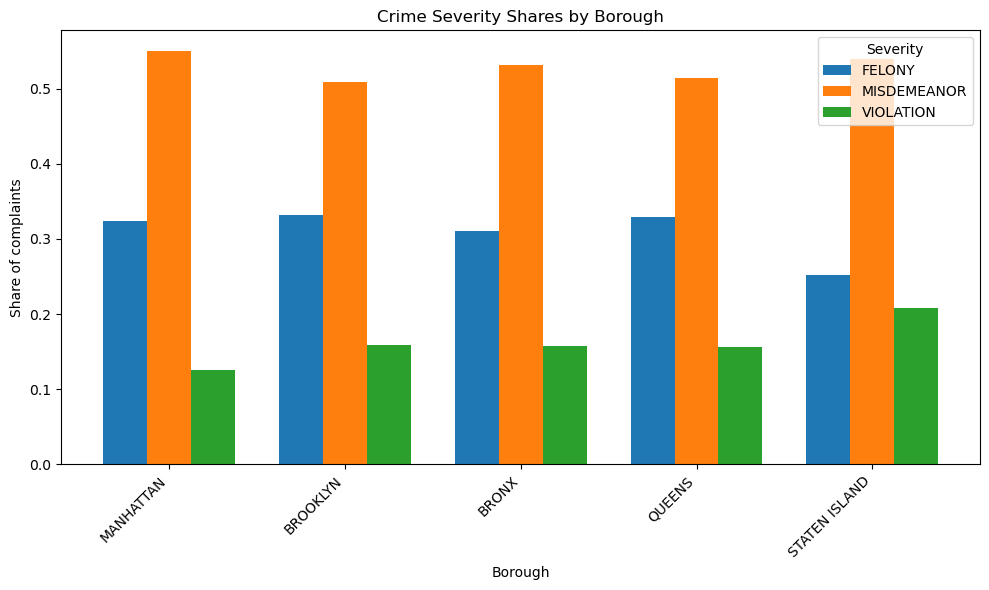

In [54]:
x = np.arange(len(boroughs))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, sev in enumerate(valid_law):
    ax.bar(
        x + (i - 1) * width,              # center the 3 bars on each borough
        shares_severity[sev].values,
        width,
        label=sev
    )

ax.set_xticks(x)
ax.set_xticklabels(boroughs, rotation=45, ha='right')
ax.set_ylabel("Share of complaints")
ax.set_xlabel("Borough")
ax.set_title("Crime Severity Shares by Borough")
ax.legend(title="Severity")

plt.tight_layout()
plt.show()


In [55]:
valid_law = ['FELONY', 'MISDEMEANOR', 'VIOLATION']

# ---- 1. Start from crime data & clean ----
df = crime.copy()

# Use imputed borough if available, else BORO_NM
if 'BORO_NM_IMPUTED' in df.columns:
    boro_col = 'BORO_NM_IMPUTED'
    df = df[df[boro_col] != 'UNKNOWN']
else:
    boro_col = 'BORO_NM'
    df = df[df[boro_col] != '(null)']

# Ensure we have a YEAR column
if 'YEAR' not in df.columns:
    df['YEAR'] = pd.to_datetime(df['CMPLNT_FR_DT']).dt.year

# Keep only needed columns
df = df[[boro_col, 'LAW_CAT_CD', 'YEAR']].dropna()

# Keep just the 3 categories
df = df[df['LAW_CAT_CD'].isin(valid_law)]

# ---- 2. Crosstab: for each (borough, year), shares of FELONY/MISD/VIOLATION ----
ct = pd.crosstab(
    [df[boro_col], df['YEAR']],
    df['LAW_CAT_CD'],
    normalize='index'
)

years = sorted(df['YEAR'].unique())
print("Years available:", years)

Years available: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [60]:
from ipywidgets import interact, IntSlider
valid_law = ['FELONY', 'MISDEMEANOR', 'VIOLATION']

# convert np.int64 years to plain Python ints
years = sorted(int(y) for y in df['YEAR'].unique())
print("Years available:", years)

def plot_severity_year(year):
    # slice (borough, year) -> severity shares
    try:
        shares_year = ct.xs(year, level='YEAR')
    except KeyError:
        print(f"No data for year {year}")
        return

    # borough order
    boroughs = ['MANHATTAN', 'BROOKLYN', 'BRONX', 'QUEENS', 'STATEN ISLAND']
    boroughs = [b for b in boroughs if b in shares_year.index]

    shares_year = shares_year.loc[boroughs, valid_law]

    x = np.arange(len(boroughs))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))

    for i, sev in enumerate(valid_law):
        ax.bar(
            x + (i - 1) * width,
            shares_year[sev].values,
            width,
            label=sev
        )

    ax.set_xticks(x)
    ax.set_xticklabels(boroughs, rotation=45, ha='right')
    ax.set_ylabel("Share of complaints")
    ax.set_xlabel("Borough")
    ax.set_title(f"Crime Severity Shares by Borough – {year}")
    ax.legend(
    title="Severity",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),  # just outside the axes to the right
    borderaxespad=0.,
    frameon=True
)

plt.tight_layout()
plt.show()

interact(
    plot_severity_year,
    year=IntSlider(
        min=min(years),
        max=max(years),
        step=1,
        value=max(years),
        description='Year'
    )
)

Years available: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


<Figure size 640x480 with 0 Axes>

interactive(children=(IntSlider(value=2024, description='Year', max=2024, min=2015), Output()), _dom_classes=(…

<function __main__.plot_severity_year(year)>